# ATP Tennis Match Prediction: EDA & Feature Engineering (2000–2026)

> [!TIP]
> ### ⚡ Local Kernel Fast-Boot Guide (<2s Execution)
> **Goal**: Launch interactive prediction widgets without re-running data extraction & model training (~45 min).
> 
> **Prerequisites**:
> - Files in workspace root: `atp_inference_bundle.joblib` (~694 KB), `test_features.csv` (~3.3 MB)
> - Python deps: `lightgbm`, `ipywidgets`, `scikit-learn`, `joblib`, `pandas`
>
> **Sequential Run Path**:
> 1. **Setup**: Run [Cell 1: Imports & Parameters](#configuration-parameters)
> 2. **Load Bundle**: Jump to [Phase 9.0: Fast-boot Loader](#90-fast-boot-inference-loader-post-restart-cold-start) & execute
> 3. **Init Renderer**: Run [Phase 9.3: Rich HTML Card Generator](#93-rich-html-dashboard-card-generator)
> 4. **Launch UI**: Run [Phase 9.4: Interactive Two-Tab Widget Interface](#94-interactive-two-tab-widget-interface)
>
> ⛔ **DO NOT RUN**: Phases 1–8 (upstream ETL/training) & Phase 9.2 (bundle export).

This notebook executes a comprehensive Exploratory Data Analysis (EDA) and feature engineering 
pipeline for ATP tennis match outcome prediction using daily pull dataset from Kaggle.

### Notebook Highlights:
- **Zero Data Leakage**: All rolling, expanding, head-to-head, and fatigue features are strictly computed using match data available prior to each match date.
- **7-Phase Structure**:
  1. Data Loading & Cleaning
  2. Distributions & Baseline Performance
  3. Score Parsing & Match-Level Granularity
  4. Feature Engineering (Direct Diffs, 3-Tier Rolling Stats, Surface Stats, H2H, Fatigue, Contextual)
  5. EDA Visualizations on Engineered Features
  6. Feature Selection (Multicollinearity Removal via correlation thresholding)
  7. Train/Test Temporal Export (Train: 2000-2023, Test: 2024-2026)

In [1]:
import os
import re
import time
import warnings
import numpy as np
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import kagglehub
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings("ignore")

# Configuration Parameters
CUTOFF_YEAR = 2023
TRAIN_RANGE = (2000, CUTOFF_YEAR)
TEST_RANGE = (CUTOFF_YEAR + 1, 2026)
SHORT_WINDOW = 10          # Last N matches for short-term form
MEDIUM_WINDOW_WEEKS = 52   # 52 weeks (365 days) for medium-term form
H2H_COLD_START = 0.5       # Default win probability for first-time matchups

# Visualization Setup
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

print("Configuration parameters loaded successfully.")
print(f"Train Period: {TRAIN_RANGE[0]} - {TRAIN_RANGE[1]}")
print(f"Test Period:  {TEST_RANGE[0]} - {TEST_RANGE[1]}")

Configuration parameters loaded successfully.
Train Period: 2000 - 2023
Test Period:  2024 - 2026


## Phase 1: Data Loading & Cleaning

In this phase, we load the ATP tennis dataset using `kagglehub`, convert sentinel negative values (`-1`) 
to `np.nan`, audit missing values, remove duplicates, inspect surface cardinality, and verify data sanity.


=== Phase 1: Data Loading & Cleaning ===


Using Colab cache for faster access to the 'atp-tennis-2000-2023daily-pull' dataset.
Loaded raw dataset with shape: (68353, 17)

Missing Values Audit:
        Missing Count  Percentage (%)
Rank_1             14        0.020482
Rank_2             12        0.017556
Pts_1           15652       22.898775
Pts_2           15653       22.900238
Odd_1            3783        5.534505
Odd_2            3781        5.531579


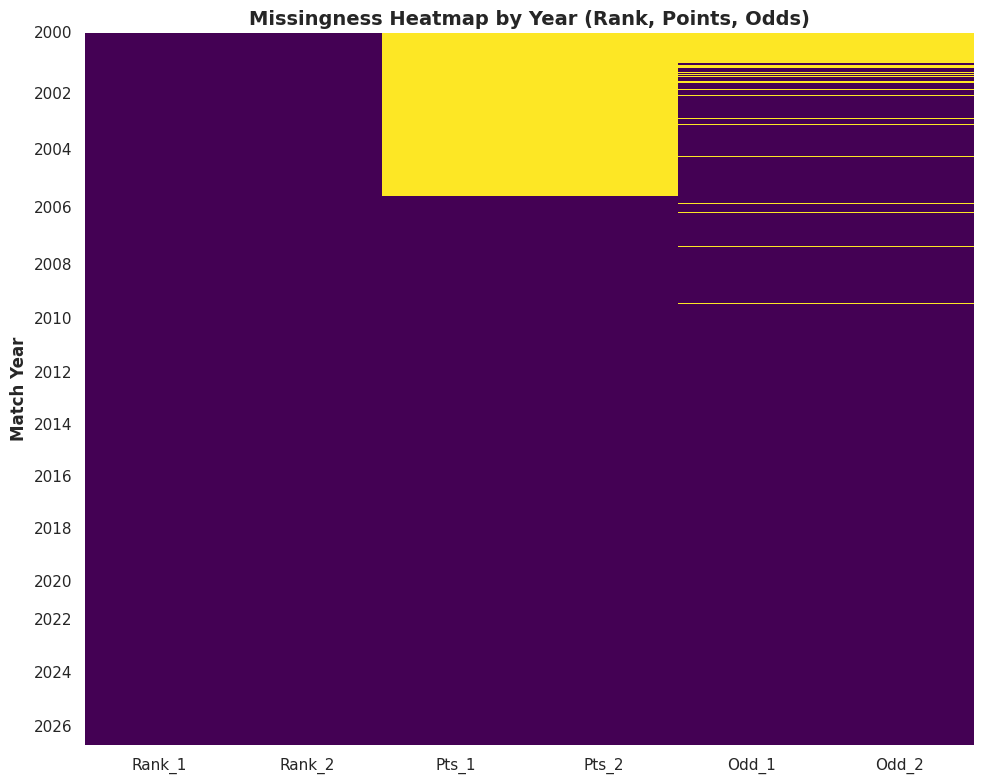


Duplicate matches detected (same Date + Player_1 + Player_2): 2
Dataset shape after dropping duplicates: (68351, 18)

Surface Cardinality Distribution:
Surface
Hard      36834
Clay      22152
Grass      7733
Carpet     1632
Name: count, dtype: int64
Latest year with 'Carpet' surface in dataset: 2009
Matches with invalid odds (<= 1.0): 94
Target distribution (Player_1 Win Rate): 0.5000 (34175/68351)
Phase 1 completed in 21.89s. Cleaned shape: (68351, 19)


In [43]:
print("\n=== Phase 1: Data Loading & Cleaning ===")
t_start = time.time()

# 1. Load dataset via kagglehub
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
    "dissfya/atp-tennis-2000-2023daily-pull/versions/1146",
    "atp_tennis.csv",
)
print(f"Loaded raw dataset with shape: {df.shape}")

# 2. Parse Date to datetime and sort chronologically
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df["match_id"] = np.arange(len(df))

# 3. Sentinel values conversion (-1 or <= 0 in numeric columns to np.nan)
num_sentinel_cols = ["Rank_1", "Rank_2", "Pts_1", "Pts_2", "Odd_1", "Odd_2"]
for col in num_sentinel_cols:
    df[col] = df[col].apply(lambda x: np.nan if pd.isna(x) or x <= 0 else float(x))

# 4. Missing values audit
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing_counts, "Percentage (%)": missing_pct})
print("\nMissing Values Audit:")
print(missing_df[missing_df["Missing Count"] > 0])

# Heatmap of missing numerical values with year intervals on Y-axis
year_ticks = df.groupby(df["Date"].dt.year).head(1).index
year_labels = df.loc[year_ticks, "Date"].dt.year
interval_mask = year_labels % 2 == 0
step_ticks = year_ticks[interval_mask]
step_labels = year_labels[interval_mask]

plt.figure(figsize=(10, 8))
ax = sns.heatmap(df[num_sentinel_cols].isna(), cbar=False, cmap="viridis")
ax.set_yticks(step_ticks)
ax.set_yticklabels(step_labels, rotation=0)
plt.ylabel("Match Year", fontsize=12, fontweight="bold")
plt.title("Missingness Heatmap by Year (Rank, Points, Odds)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 5. Duplicate detection (same date + same players)
dups = df.duplicated(subset=["Date", "Player_1", "Player_2"], keep="first")
dup_count = dups.sum()
print(f"\nDuplicate matches detected (same Date + Player_1 + Player_2): {dup_count}")
if dup_count > 0:
    df = df[~dups].reset_index(drop=True)
    df["match_id"] = np.arange(len(df))
    print(f"Dataset shape after dropping duplicates: {df.shape}")

# 6. Surface cardinality check
print("\nSurface Cardinality Distribution:")
print(df["Surface"].value_counts(dropna=False))

# Note on Carpet surface (discontinued on ATP Tour post-2009)
carpet_latest_year = df[df["Surface"] == "Carpet"]["Date"].dt.year.max()
print(f"Latest year with 'Carpet' surface in dataset: {carpet_latest_year}")

# 7. Sanity checks (odds > 1.0, ranks > 0)
invalid_odds = ((df["Odd_1"] <= 1.0) | (df["Odd_2"] <= 1.0)).sum()
print(f"Matches with invalid odds (<= 1.0): {invalid_odds}")
df.loc[df["Odd_1"] <= 1.0, "Odd_1"] = np.nan
df.loc[df["Odd_2"] <= 1.0, "Odd_2"] = np.nan

# 8. Create binary target column
df["target"] = (df["Winner"] == df["Player_1"]).astype(int)
print(f"Target distribution (Player_1 Win Rate): {df['target'].mean():.4f} ({df['target'].sum()}/{len(df)})")
print(f"Phase 1 completed in {time.time() - t_start:.2f}s. Cleaned shape: {df.shape}")

## Phase 2: Distributions & Baseline Performance

We analyze match volume trends, surface distributions across seasons, tournament series tiers, 
and establish baseline predictive benchmarks (Favorite Win Rate and Implied Odds Brier Score).


=== Phase 2: Distributions & Baseline Performance ===


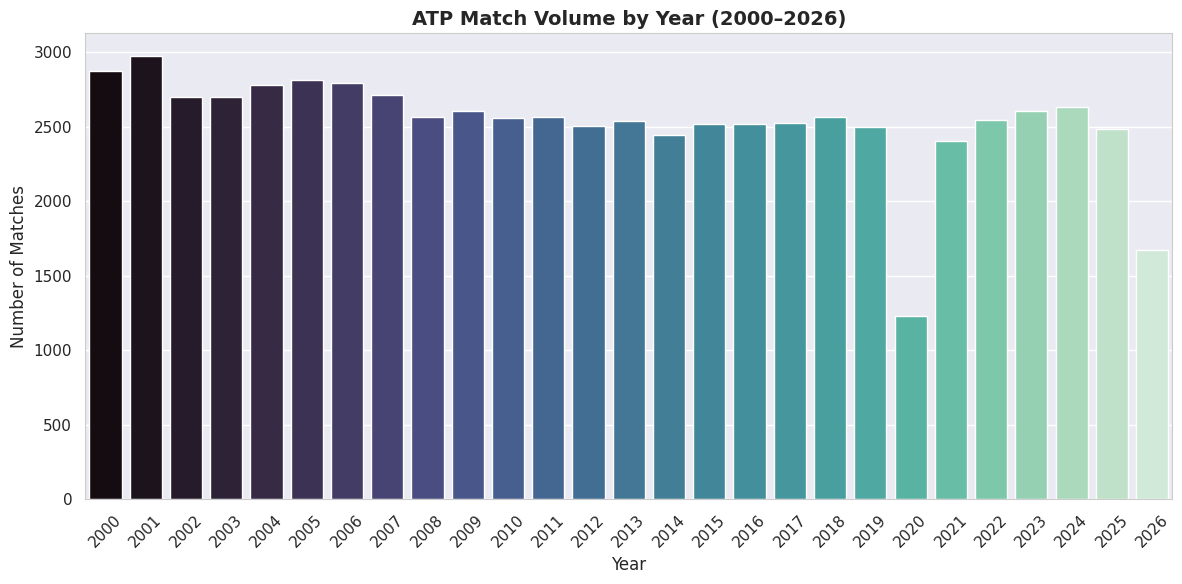

<Figure size 1200x600 with 0 Axes>

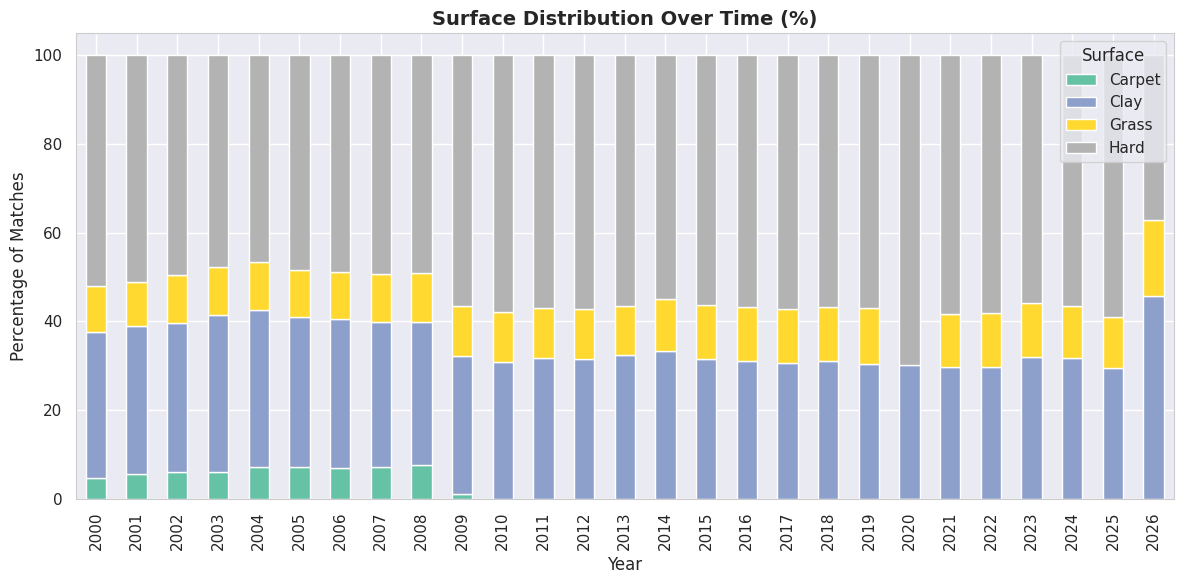

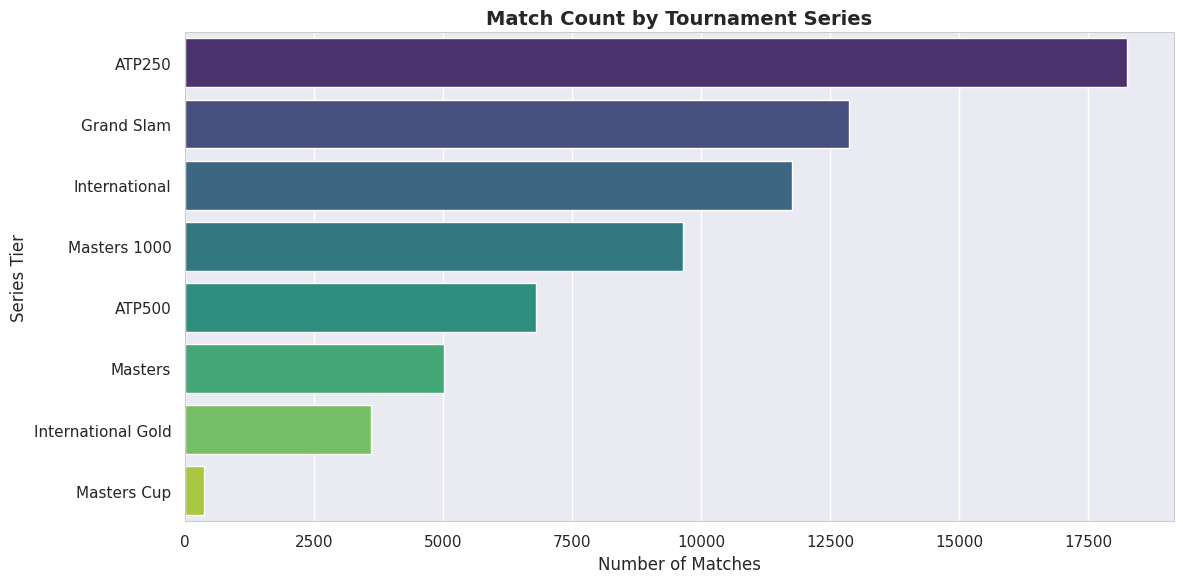

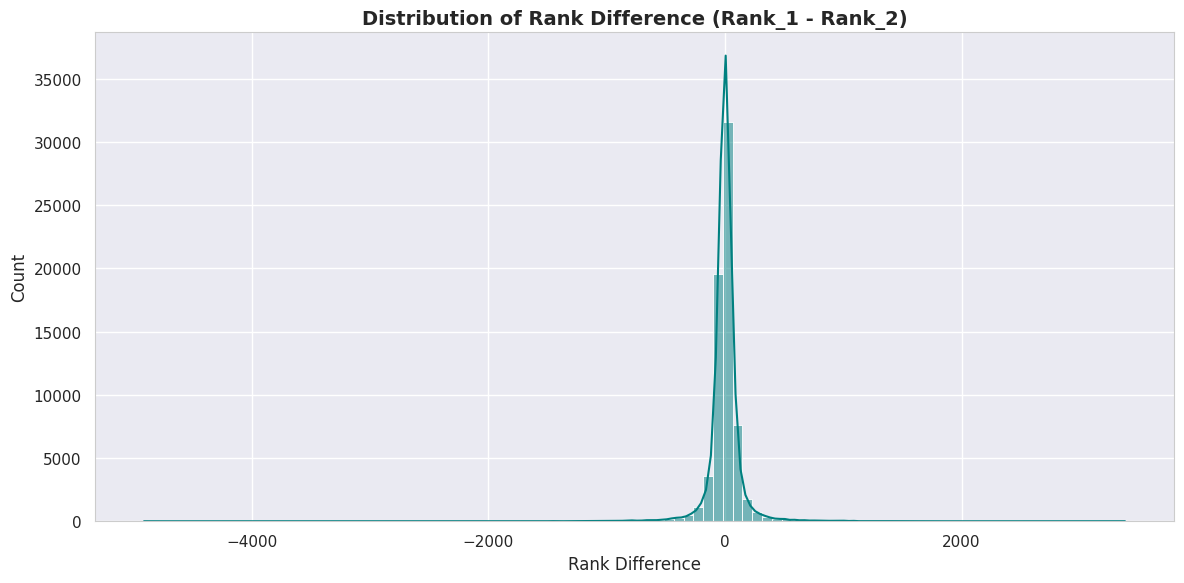


Baseline Benchmark 1 - Favorite (Lower Rank) Win Rate: 65.33% (44638/68324)
Baseline Benchmark 2 - Odds Implied Favorite Accuracy: 69.64%
Baseline Benchmark 3 - Odds Implied Brier Score:       0.1959

Upset Rate by Surface:
         Total Matches  Upset Rate (%)
Surface                               
Carpet            1632       37.745098
Clay             22143       35.469449
Grass             7729       34.571096
Hard             36820       34.068441

Upset Rate by Tournament Series:
                    Total Matches  Upset Rate (%)
Series                                           
ATP250                      18243       37.713095
ATP500                       6806       33.911255
Grand Slam                  12871       28.474866
International               11730       35.583973
International Gold           3617       36.577274
Masters                      5028       37.330947
Masters 1000                 9644       34.498134
Masters Cup                   385       34.285714


In [44]:
print("\n=== Phase 2: Distributions & Baseline Performance ===")

df["Year"] = df["Date"].dt.year

# 1. Match volume by year
plt.figure(figsize=(12, 6))
year_counts = df["Year"].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, palette="mako")
plt.title("ATP Match Volume by Year (2000–2026)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Surface distribution over time (stacked bar chart)
plt.figure(figsize=(12, 6))
surf_year = pd.crosstab(df["Year"], df["Surface"], normalize="index") * 100
surf_year.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2")
plt.title("Surface Distribution Over Time (%)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Percentage of Matches")
plt.legend(title="Surface")
plt.tight_layout()
plt.show()

# 3. Series / Tier distribution
plt.figure(figsize=(12, 6))
series_counts = df["Series"].value_counts()
sns.barplot(x=series_counts.values, y=series_counts.index, palette="viridis")
plt.title("Match Count by Tournament Series", fontsize=14, fontweight="bold")
plt.xlabel("Number of Matches")
plt.ylabel("Series Tier")
plt.tight_layout()
plt.show()

# 4. Rank difference distribution
valid_ranks_mask = df["Rank_1"].notna() & df["Rank_2"].notna()
df["temp_rank_diff"] = df["Rank_1"] - df["Rank_2"]

plt.figure(figsize=(12, 6))
sns.histplot(df.loc[valid_ranks_mask, "temp_rank_diff"], bins=100, kde=True, color="teal")
plt.title("Distribution of Rank Difference (Rank_1 - Rank_2)", fontsize=14, fontweight="bold")
plt.xlabel("Rank Difference")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 5. Baseline Accuracy: Favorite (lower rank) Win Rate
# Favorite is player with lower numerical rank (higher standing)
valid_rank_matches = df[valid_ranks_mask & (df["Rank_1"] != df["Rank_2"])].copy()
valid_rank_matches["favorite_is_p1"] = valid_rank_matches["Rank_1"] < valid_rank_matches["Rank_2"]
valid_rank_matches["favorite_won"] = (
    (valid_rank_matches["favorite_is_p1"] & (valid_rank_matches["target"] == 1)) |
    (~valid_rank_matches["favorite_is_p1"] & (valid_rank_matches["target"] == 0))
)
baseline_favorite_acc = valid_rank_matches["favorite_won"].mean()
print(f"\nBaseline Benchmark 1 - Favorite (Lower Rank) Win Rate: {baseline_favorite_acc * 100:.2f}% "
      f"({valid_rank_matches['favorite_won'].sum()}/{len(valid_rank_matches)})")

# 6. Baseline Brier Score: Implied Probabilities from Betting Odds
valid_odds_mask = df["Odd_1"].notna() & df["Odd_2"].notna()
valid_odds_df = df[valid_odds_mask].copy()

# Raw inverse odds normalized to sum to 1 (removing bookmaker margin/overround)
inv_odd_1 = 1.0 / valid_odds_df["Odd_1"]
inv_odd_2 = 1.0 / valid_odds_df["Odd_2"]
prob_implied_1 = inv_odd_1 / (inv_odd_1 + inv_odd_2)

# Brier score = mean((implied_prob_1 - target)^2)
brier_score_odds = np.mean((prob_implied_1 - valid_odds_df["target"]) ** 2)
odds_favorite_correct = ((prob_implied_1 > 0.5) == (valid_odds_df["target"] == 1)).mean()

print(f"Baseline Benchmark 2 - Odds Implied Favorite Accuracy: {odds_favorite_correct * 100:.2f}%")
print(f"Baseline Benchmark 3 - Odds Implied Brier Score:       {brier_score_odds:.4f}")

# 7. Upset Rate Analysis by Surface and Series
valid_rank_matches["is_upset"] = ~valid_rank_matches["favorite_won"]

print("\nUpset Rate by Surface:")
upset_surf = valid_rank_matches.groupby("Surface")["is_upset"].agg(["count", "mean"])
upset_surf["mean"] = upset_surf["mean"] * 100
upset_surf.columns = ["Total Matches", "Upset Rate (%)"]
print(upset_surf)

print("\nUpset Rate by Tournament Series:")
upset_series = valid_rank_matches.groupby("Series")["is_upset"].agg(["count", "mean"])
upset_series["mean"] = upset_series["mean"] * 100
upset_series.columns = ["Total Matches", "Upset Rate (%)"]
print(upset_series)

df.drop(columns=["temp_rank_diff"], inplace=True)

## Phase 3: Score Parsing & Match Features

We extract detailed granular statistics directly from the match `Score` strings:
- Sets won/lost per player, total sets
- Tiebreaks played, tiebreaks won
- Comeback victories (winning match after losing first set)
- Bagels dealt/received (6-0 sets)
- Breadsticks dealt/received (6-1 sets)
- Total games won/lost
- Match retirements and walkovers


=== Phase 3: Score Parsing & Granular Match Features ===


Score parsing completed in 1.80s.
Total retirements/walkovers detected: 6
Total comeback victories: Player 1 = 6604, Player 2 = 6645


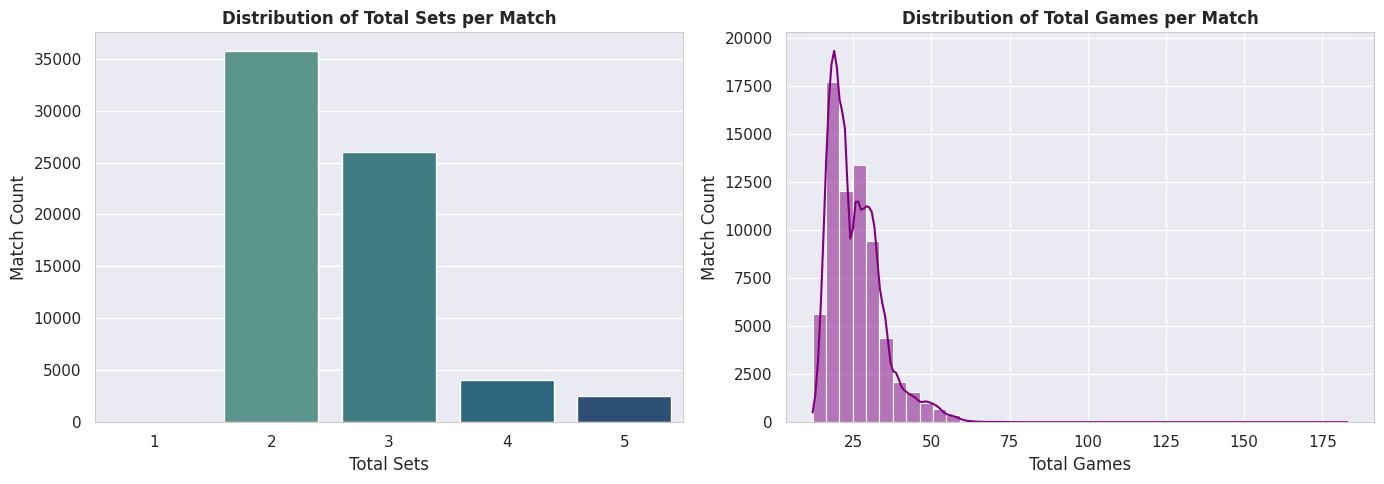

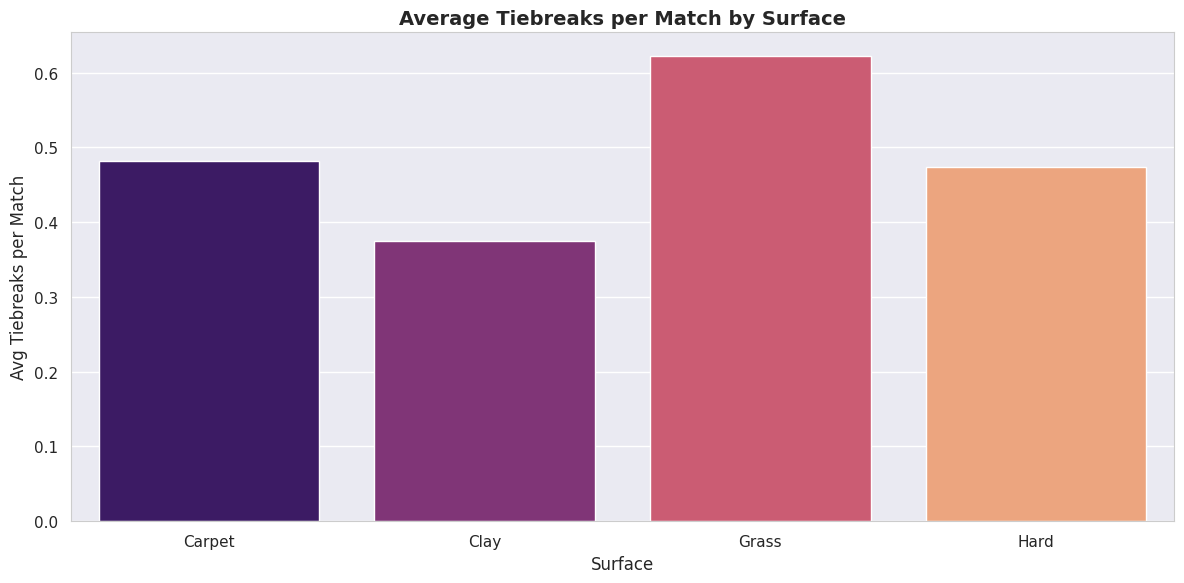

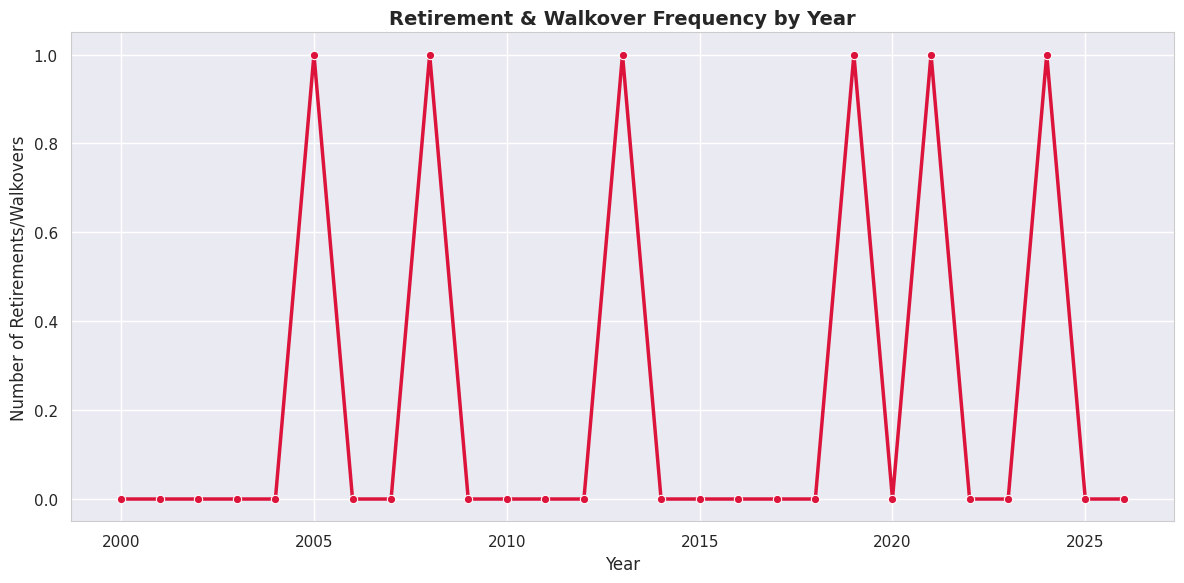

In [45]:
print("\n=== Phase 3: Score Parsing & Granular Match Features ===")
t_score = time.time()

def parse_score_robust(score_str, winner, player_1):
    score_str = str(score_str).strip()
    is_p1_winner = (winner == player_1)
    
    # Retirement / Walkover detection via keyword or incomplete set
    is_ret = int(bool(re.search(r"(?i)(ret\.?|w/o|walkover|def\.?)", score_str)))
    score_clean = re.sub(r"(?i)(ret\.?|w/o|walkover|def\.?)", "", score_str).strip()
    tokens = score_clean.split()
    
    g1_sum, g2_sum = 0, 0
    tb_played, tb_w1, tb_w2 = 0, 0, 0
    bagels_1, bagels_2 = 0, 0
    bs_1, bs_2 = 0, 0
    first_set_loser = 0
    sets_won_1, sets_won_2 = 0, 0
    valid_sets = 0
    
    for idx, token in enumerate(tokens):
        # Match set scores e.g., 6-4, 7-6(5), 7-6, 13-11, 0-6, 6-1
        m = re.match(r"^(\d+)-(\d+)(?:\((\d+)\))?$", token)
        if not m:
            continue
            
        g1, g2 = int(m.group(1)), int(m.group(2))
        g1_sum += g1
        g2_sum += g2
        valid_sets += 1
        
        # Tiebreak check: explicit (x) notation OR 7-6 / 6-7
        is_tb = (m.group(3) is not None) or (g1 == 7 and g2 == 6) or (g1 == 6 and g2 == 7)
        if is_tb:
            tb_played += 1
            if g1 > g2:
                tb_w1 += 1
            elif g2 > g1:
                tb_w2 += 1
                
        # First set loser determination
        if idx == 0:
            if g1 > g2:
                first_set_loser = 2
            elif g2 > g1:
                first_set_loser = 1
                
        # Set winner tracking
        if g1 > g2:
            sets_won_1 += 1
        elif g2 > g1:
            sets_won_2 += 1
            
        # Bagels (6-0 / 0-6)
        if g1 == 6 and g2 == 0:
            bagels_1 += 1
        elif g1 == 0 and g2 == 6:
            bagels_2 += 1
            
        # Breadsticks (6-1 / 1-6)
        if g1 == 6 and g2 == 1:
            bs_1 += 1
        elif g1 == 1 and g2 == 6:
            bs_2 += 1

        # Check for incomplete set indicative of retirement (e.g. 2-1 without 6+ games)
        if g1 < 6 and g2 < 6 and not (g1 == 7 or g2 == 7):
            is_ret = 1
            
    cb1 = int(is_p1_winner and first_set_loser == 1)
    cb2 = int((not is_p1_winner) and first_set_loser == 2)
    
    return {
        "sets_won_1": sets_won_1,
        "sets_lost_1": sets_won_2,
        "sets_won_2": sets_won_2,
        "sets_lost_2": sets_won_1,
        "total_sets": valid_sets,
        "tiebreaks_played": tb_played,
        "tiebreaks_won_1": tb_w1,
        "tiebreaks_won_2": tb_w2,
        "comeback_1": cb1,
        "comeback_2": cb2,
        "bagels_dealt_1": bagels_1,
        "bagels_received_1": bagels_2,
        "breadsticks_dealt_1": bs_1,
        "breadsticks_received_1": bs_2,
        "games_won_1": g1_sum,
        "games_lost_1": g2_sum,
        "games_won_2": g2_sum,
        "games_lost_2": g1_sum,
        "is_retirement": is_ret,
        "first_set_loser": first_set_loser
    }

parsed_records = df.apply(lambda r: parse_score_robust(r["Score"], r["Winner"], r["Player_1"]), axis=1)
parsed_df = pd.DataFrame(list(parsed_records))
df = pd.concat([df, parsed_df], axis=1)

print(f"Score parsing completed in {time.time() - t_score:.2f}s.")
print(f"Total retirements/walkovers detected: {df['is_retirement'].sum()}")
print(f"Total comeback victories: Player 1 = {df['comeback_1'].sum()}, Player 2 = {df['comeback_2'].sum()}")

# EDA on parsed score features
# 1. Distribution of match lengths (total sets & total games)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="total_sets", ax=axes[0], palette="crest")
axes[0].set_title("Distribution of Total Sets per Match", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Total Sets")
axes[0].set_ylabel("Match Count")

total_games = df["games_won_1"] + df["games_lost_1"]
sns.histplot(total_games, bins=40, kde=True, ax=axes[1], color="darkindigo" if "darkindigo" in plt.colormaps else "purple")
axes[1].set_title("Distribution of Total Games per Match", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Total Games")
axes[1].set_ylabel("Match Count")
plt.tight_layout()
plt.show()

# 2. Tiebreak frequency by surface
plt.figure(figsize=(12, 6))
tb_surf = df.groupby("Surface")["tiebreaks_played"].mean()
sns.barplot(x=tb_surf.index, y=tb_surf.values, palette="magma")
plt.title("Average Tiebreaks per Match by Surface", fontsize=14, fontweight="bold")
plt.xlabel("Surface")
plt.ylabel("Avg Tiebreaks per Match")
plt.tight_layout()
plt.show()

# 3. Retirement frequency by year
plt.figure(figsize=(12, 6))
ret_year = df.groupby("Year")["is_retirement"].sum()
sns.lineplot(x=ret_year.index, y=ret_year.values, marker="o", color="crimson", linewidth=2.5)
plt.title("Retirement & Walkover Frequency by Year", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Retirements/Walkovers")
plt.tight_layout()
plt.show()

## Phase 4: Feature Engineering

Strict temporal ordering is preserved. All rolling/expanding features use strictly past data (`closed='left'` or `.shift(1)`).

Calculated Features:
- **4a. Direct Differences**: `rank_diff`, `pts_diff`, `odds_diff`, `implied_prob_diff`
- **4b. Rolling Player Stats (3 Tiers)**:
  - Short (last 10 matches)
  - Medium (last 52 weeks / 365 days)
  - Career (all expanding past matches)
  - Metrics: Win rate, Tiebreak win rate, Comeback rate, Bagel/breadstick rate, Avg games per set, Retirement freq.
- **4c. Surface-Specific Stats**: Career surface win rates for P1, P2, and surface_winrate_diff
- **4d. Head-to-Head (H2H)**: Prior meetings H2H win rate, match count, surface H2H win rate, surface match count
- **4e. Fatigue**: Days since last match, matches in last 14d, matches in last 30d (diffs)
- **4f. Contextual**: Encoded surface, encoded series, is_grand_slam, form_divergence

In [46]:
print("\n=== Phase 4: Feature Engineering ===")
t_fe = time.time()

# Ensure strictly sorted by date and match_id
df = df.sort_values(["Date", "match_id"]).reset_index(drop=True)

# --- 4a. Direct Differences ---
df["rank_diff"] = df["Rank_1"] - df["Rank_2"]
df["pts_diff"] = df["Pts_1"] - df["Pts_2"]
df["odds_diff"] = df["Odd_1"] - df["Odd_2"]

# Implied probabilities from odds (normalized)
valid_odds_cond = (df["Odd_1"] > 1.0) & (df["Odd_2"] > 1.0)
ip1 = np.where(valid_odds_cond, (1.0 / df["Odd_1"]) / ((1.0 / df["Odd_1"]) + (1.0 / df["Odd_2"])), np.nan)
ip2 = np.where(valid_odds_cond, (1.0 / df["Odd_2"]) / ((1.0 / df["Odd_1"]) + (1.0 / df["Odd_2"])), np.nan)
df["implied_prob_diff"] = ip1 - ip2

print("Completed 4a. Direct Differences.")

# --- 4b & 4c & 4e. Player-Match Long Table for Past-Only Rolling Stats ---
p1_table = pd.DataFrame({
    "match_id": df["match_id"],
    "Date": df["Date"],
    "player": df["Player_1"],
    "opponent": df["Player_2"],
    "Surface": df["Surface"],
    "won": (df["Winner"] == df["Player_1"]).astype(int),
    "sets_total": df["total_sets"],
    "tb_played": df["tiebreaks_played"],
    "tb_won": df["tiebreaks_won_1"],
    "lost_1st_set": (df["first_set_loser"] == 1).astype(int),
    "comeback_win": df["comeback_1"],
    "bb_dealt": df["bagels_dealt_1"] + df["breadsticks_dealt_1"],
    "games_won": df["games_won_1"],
    "is_retirement": df["is_retirement"],
    "p_num": 1
})

p2_table = pd.DataFrame({
    "match_id": df["match_id"],
    "Date": df["Date"],
    "player": df["Player_2"],
    "opponent": df["Player_1"],
    "Surface": df["Surface"],
    "won": (df["Winner"] == df["Player_2"]).astype(int),
    "sets_total": df["total_sets"],
    "tb_played": df["tiebreaks_played"],
    "tb_won": df["tiebreaks_won_2"],
    "lost_1st_set": (df["first_set_loser"] == 2).astype(int),
    "comeback_win": df["comeback_2"],
    "bb_dealt": df["bagels_received_1"] + df["breadsticks_received_1"],
    "games_won": df["games_won_2"],
    "is_retirement": df["is_retirement"],
    "p_num": 2
})

long_df = pd.concat([p1_table, p2_table], ignore_index=True)
long_df = long_df.sort_values(["player", "Date", "match_id"]).reset_index(drop=True)

gb_p = long_df.groupby("player")

# 1. Career Expanding Features (strictly past matches)
long_df["prev_matches"] = gb_p.cumcount()
long_df["career_wins"] = gb_p["won"].cumsum() - long_df["won"]
long_df["career_winrate"] = np.where(long_df["prev_matches"] > 0, long_df["career_wins"] / long_df["prev_matches"], 0.5)

long_df["career_tb_played"] = gb_p["tb_played"].cumsum() - long_df["tb_played"]
long_df["career_tb_won"] = gb_p["tb_won"].cumsum() - long_df["tb_won"]
long_df["career_tb_winrate"] = np.where(long_df["career_tb_played"] > 0, long_df["career_tb_won"] / long_df["career_tb_played"], 0.5)

long_df["career_lost_1st"] = gb_p["lost_1st_set"].cumsum() - long_df["lost_1st_set"]
long_df["career_comebacks"] = gb_p["comeback_win"].cumsum() - long_df["comeback_win"]
long_df["career_comeback_rate"] = np.where(long_df["career_lost_1st"] > 0, long_df["career_comebacks"] / long_df["career_lost_1st"], 0.0)

long_df["career_sets_total"] = gb_p["sets_total"].cumsum() - long_df["sets_total"]
long_df["career_bb_dealt"] = gb_p["bb_dealt"].cumsum() - long_df["bb_dealt"]
long_df["career_bb_rate"] = np.where(long_df["career_sets_total"] > 0, long_df["career_bb_dealt"] / long_df["career_sets_total"], 0.0)

long_df["career_games_won"] = gb_p["games_won"].cumsum() - long_df["games_won"]
long_df["career_avg_games_per_set"] = np.where(long_df["career_sets_total"] > 0, long_df["career_games_won"] / long_df["career_sets_total"], 4.9)

long_df["career_retirements"] = gb_p["is_retirement"].cumsum() - long_df["is_retirement"]
long_df["career_ret_freq"] = np.where(long_df["prev_matches"] > 0, long_df["career_retirements"] / long_df["prev_matches"], 0.0)

# 2. Surface-Specific Career Win Rate
gb_ps = long_df.groupby(["player", "Surface"])
long_df["surf_prev_matches"] = gb_ps.cumcount()
long_df["surf_wins"] = gb_ps["won"].cumsum() - long_df["won"]
long_df["surface_winrate"] = np.where(long_df["surf_prev_matches"] > 0, long_df["surf_wins"] / long_df["surf_prev_matches"], 0.5)

# 3. Short Window Stats (Last 10 Matches)
shift_cols = ["won", "sets_total", "tb_played", "tb_won", "lost_1st_set", "comeback_win", "bb_dealt", "games_won"]
for col in shift_cols:
    long_df[f"{col}_s"] = gb_p[col].shift(1)

r10 = long_df.groupby("player")[[f"{c}_s" for c in shift_cols]].rolling(SHORT_WINDOW, min_periods=1)
r10_sum = r10.sum().reset_index(level=0, drop=True)
r10_cnt = r10.count().reset_index(level=0, drop=True)

long_df["short_winrate"] = (r10_sum["won_s"] / r10_cnt["won_s"]).fillna(0.5)
long_df["short_tb_winrate"] = (r10_sum["tb_won_s"] / r10_sum["tb_played_s"]).fillna(0.5)
long_df["short_comeback_rate"] = (r10_sum["comeback_win_s"] / np.maximum(r10_sum["lost_1st_set_s"], 1)).fillna(0.0)
long_df["short_bb_rate"] = (r10_sum["bb_dealt_s"] / np.maximum(r10_sum["sets_total_s"], 1)).fillna(0.0)
long_df["short_avg_games_per_set"] = (r10_sum["games_won_s"] / np.maximum(r10_sum["sets_total_s"], 1)).fillna(4.9)

# 4. Medium Window Stats (Last 52 Weeks / 365 Days)
r365 = gb_p.rolling("365D", on="Date", closed="left")
r365_sum = r365[["won", "sets_total", "tb_played", "tb_won", "lost_1st_set", "comeback_win", "bb_dealt", "games_won", "is_retirement"]].sum().reset_index(level=0, drop=True)
r365_cnt = r365["won"].count().reset_index(level=0, drop=True)

long_df["med_winrate"] = (r365_sum["won"] / r365_cnt.values).fillna(0.5).values
long_df["med_tb_winrate"] = (r365_sum["tb_won"] / r365_sum["tb_played"]).fillna(0.5).values
long_df["med_comeback_rate"] = (r365_sum["comeback_win"] / np.maximum(r365_sum["lost_1st_set"], 1)).fillna(0.0).values
long_df["med_bb_rate"] = (r365_sum["bb_dealt"] / np.maximum(r365_sum["sets_total"], 1)).fillna(0.0).values
long_df["med_avg_games_per_set"] = (r365_sum["games_won"] / np.maximum(r365_sum["sets_total"], 1)).fillna(4.9).values
long_df["med_ret_freq"] = (r365_sum["is_retirement"] / np.maximum(r365_cnt.values, 1)).fillna(0.0).values

# 5. Fatigue Features
prev_dates = gb_p["Date"].shift(1)
long_df["days_since_last"] = (long_df["Date"] - prev_dates).dt.days.fillna(60)

m14 = gb_p.rolling("14D", on="Date", closed="left")["won"].count().reset_index(level=0, drop=True)
m30 = gb_p.rolling("30D", on="Date", closed="left")["won"].count().reset_index(level=0, drop=True)
long_df["matches_14d"] = m14.fillna(0).values
long_df["matches_30d"] = m30.fillna(0).values

# Form Divergence (Short-term minus Career)
long_df["form_divergence"] = long_df["short_winrate"] - long_df["career_winrate"]

print("Completed 4b, 4c, 4e Rolling Player Stats.")

# --- Merge Player Stats back into original Match DataFrame ---
p1_feats = long_df[long_df["p_num"] == 1].sort_values("match_id").reset_index(drop=True)
p2_feats = long_df[long_df["p_num"] == 2].sort_values("match_id").reset_index(drop=True)

# List of player-level features to diff
feat_list = [
    "short_winrate", "short_tb_winrate", "short_comeback_rate", "short_bb_rate", "short_avg_games_per_set",
    "med_winrate", "med_tb_winrate", "med_comeback_rate", "med_bb_rate", "med_avg_games_per_set", "med_ret_freq",
    "career_winrate", "career_tb_winrate", "career_comeback_rate", "career_bb_rate", "career_avg_games_per_set", "career_ret_freq",
    "surface_winrate", "days_since_last", "matches_14d", "matches_30d", "form_divergence"
]

for f in feat_list:
    df[f"{f}_1"] = p1_feats[f]
    df[f"{f}_2"] = p2_feats[f]
    df[f"{f}_diff"] = p1_feats[f] - p2_feats[f]

# --- 4d. Head-to-Head (H2H) Features ---
print("Computing 4d. Head-to-Head features...")
h2h_winrate = np.full(len(df), H2H_COLD_START)
h2h_match_count = np.zeros(len(df), dtype=int)
h2h_surface_winrate = np.full(len(df), H2H_COLD_START)
h2h_surface_count = np.zeros(len(df), dtype=int)

h2h_history = {}
h2h_surf_history = {}

p1_arr = df["Player_1"].values
p2_arr = df["Player_2"].values
winner_arr = df["Winner"].values
surf_arr = df["Surface"].values

for i in range(len(df)):
    p1, p2, winner, surf = p1_arr[i], p2_arr[i], winner_arr[i], surf_arr[i]
    
    # Prior meetings lookup
    w1 = h2h_history.get((p1, p2), 0)
    w2 = h2h_history.get((p2, p1), 0)
    tot = w1 + w2
    h2h_match_count[i] = tot
    if tot > 0:
        h2h_winrate[i] = w1 / tot
        
    sw1 = h2h_surf_history.get((p1, p2, surf), 0)
    sw2 = h2h_surf_history.get((p2, p1, surf), 0)
    stot = sw1 + sw2
    h2h_surface_count[i] = stot
    if stot > 0:
        h2h_surface_winrate[i] = sw1 / stot
        
    # Update history post lookup
    if winner == p1:
        h2h_history[(p1, p2)] = w1 + 1
        h2h_surf_history[(p1, p2, surf)] = sw1 + 1
    else:
        h2h_history[(p2, p1)] = w2 + 1
        h2h_surf_history[(p2, p1, surf)] = sw2 + 1

df["h2h_winrate"] = h2h_winrate
df["h2h_match_count"] = h2h_match_count
df["h2h_surface_winrate"] = h2h_surface_winrate
df["h2h_surface_count"] = h2h_surface_count

print("Completed 4d. Head-to-Head features.")

# --- 4f. Contextual Features ---
le_surf = LabelEncoder()
df["surface_encoded"] = le_surf.fit_transform(df["Surface"].astype(str))

le_series = LabelEncoder()
df["series_encoded"] = le_series.fit_transform(df["Series"].astype(str))

df["is_grand_slam"] = ((df["Best of"] == 5) | (df["Series"] == "Grand Slam")).astype(int)

print(f"Phase 4 completed in {time.time() - t_fe:.2f}s. Total engineered columns: {df.shape[1]}")


=== Phase 4: Feature Engineering ===
Completed 4a. Direct Differences.
Completed 4b, 4c, 4e Rolling Player Stats.
Computing 4d. Head-to-Head features...
Completed 4d. Head-to-Head features.
Phase 4 completed in 2.09s. Total engineered columns: 117


## Phase 5: EDA Visualizations on Engineered Features

We inspect feature relationships with target outcome:
- Correlation matrix of diff features vs target
- Rank diff vs Win Probability (binned scatter)
- Odds implied prob vs Actual Win Rate (calibration curve)
- H2H match count distribution
- Form divergence vs Win Rate
- Fatigue differential vs Win Rate
- Mutual Information Feature Importance


=== Phase 5: EDA Visualizations on Engineered Features ===


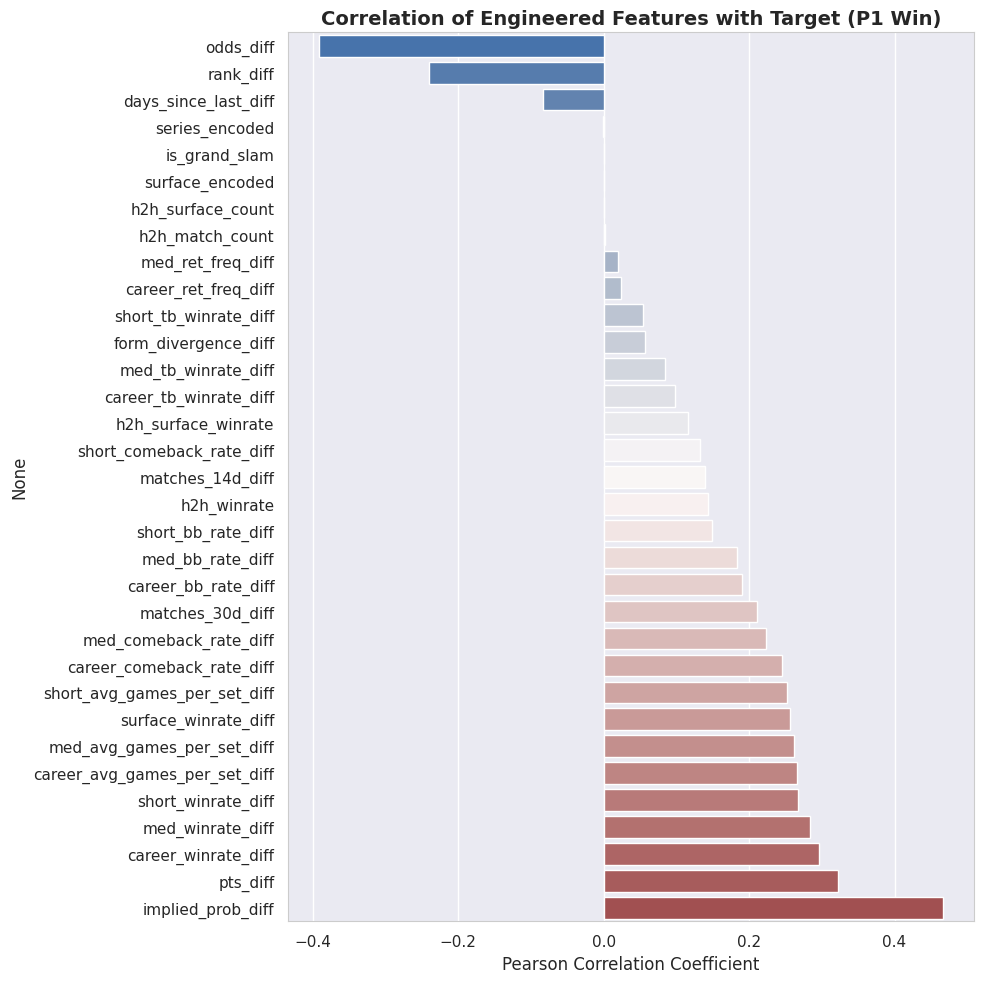

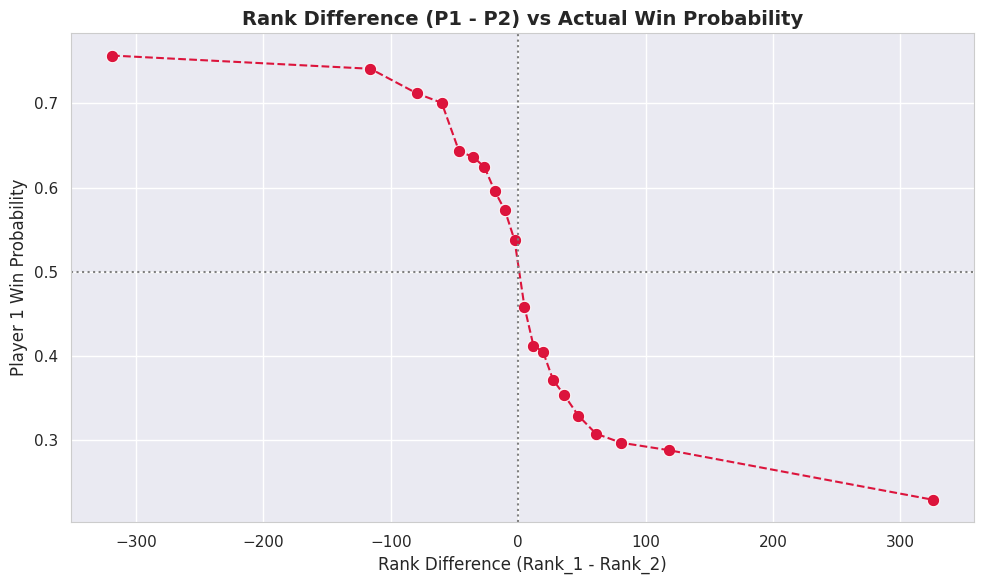

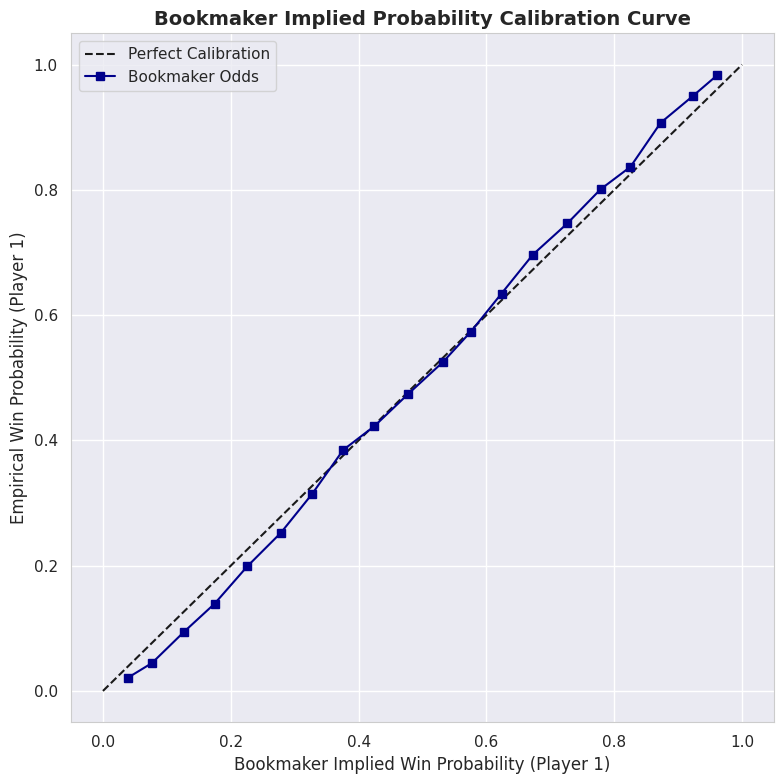

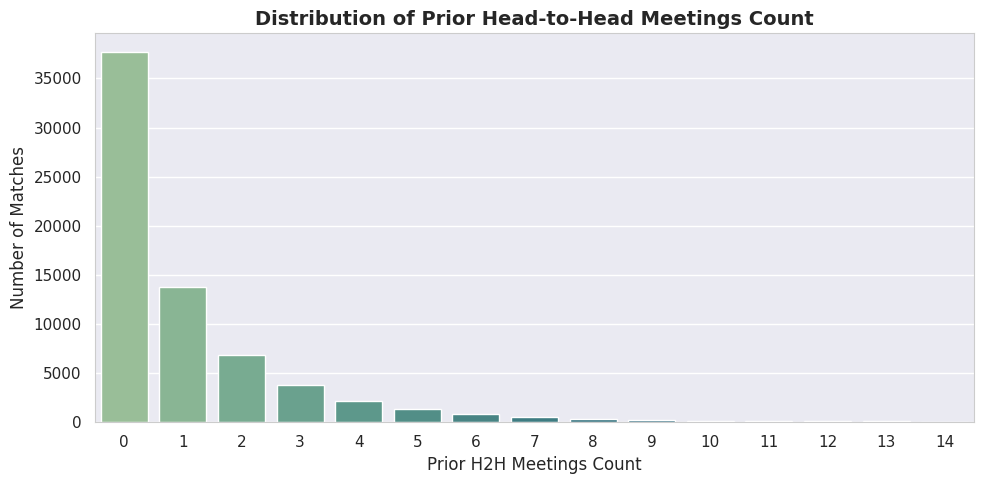

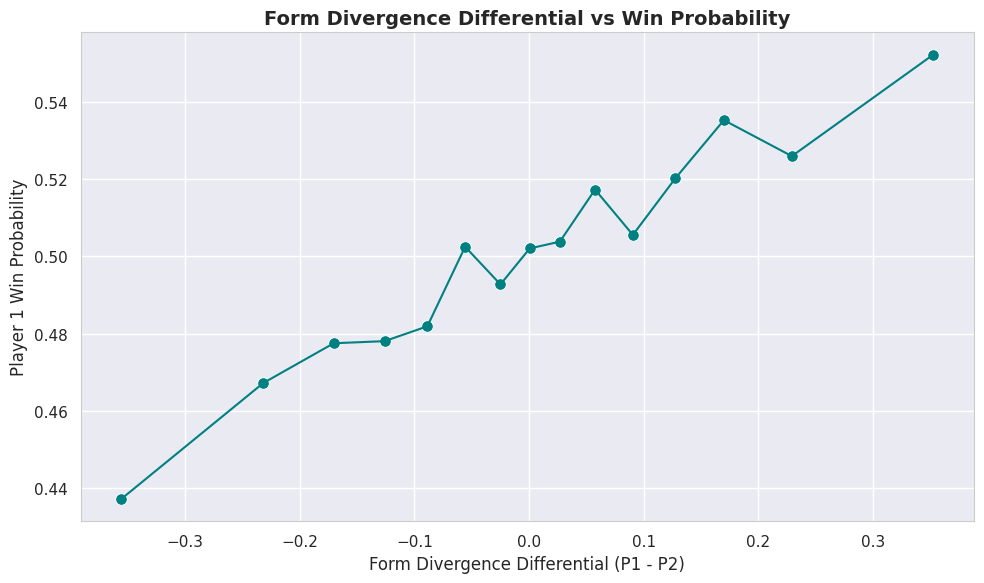

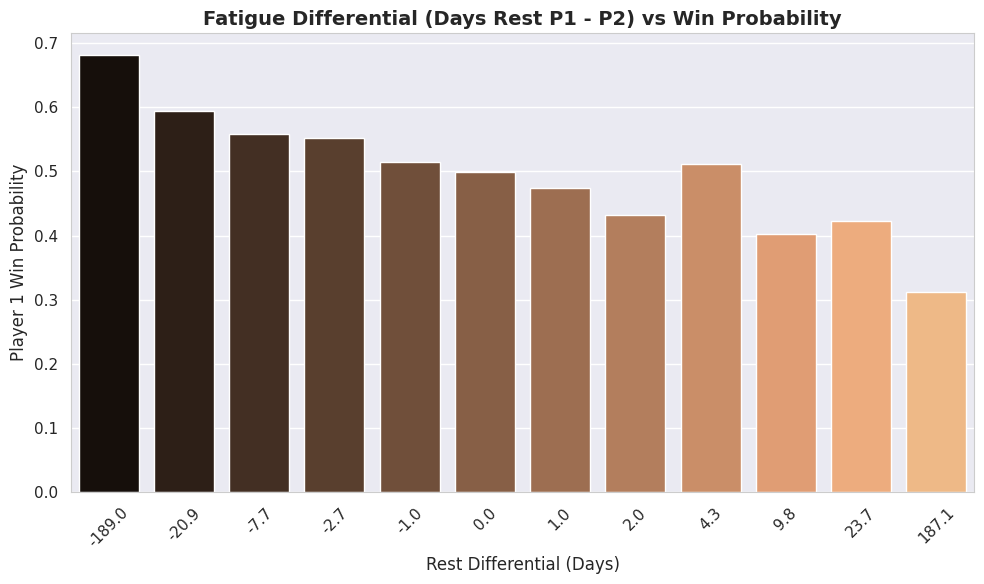


Computing Mutual Information Scores...


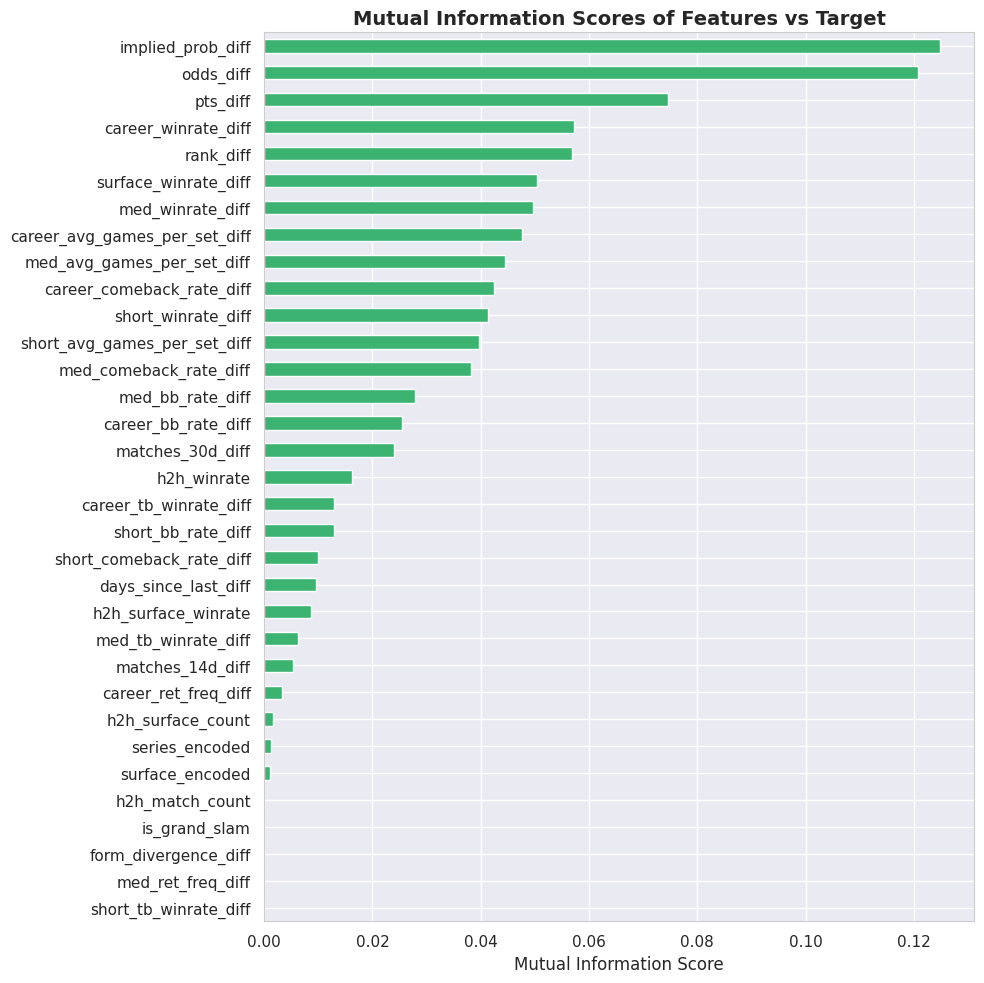

In [47]:
print("\n=== Phase 5: EDA Visualizations on Engineered Features ===")

# List of difference/relative features
diff_features = [
    "rank_diff", "pts_diff", "odds_diff", "implied_prob_diff",
    "short_winrate_diff", "short_tb_winrate_diff", "short_comeback_rate_diff", "short_bb_rate_diff", "short_avg_games_per_set_diff",
    "med_winrate_diff", "med_tb_winrate_diff", "med_comeback_rate_diff", "med_bb_rate_diff", "med_avg_games_per_set_diff", "med_ret_freq_diff",
    "career_winrate_diff", "career_tb_winrate_diff", "career_comeback_rate_diff", "career_bb_rate_diff", "career_avg_games_per_set_diff", "career_ret_freq_diff",
    "surface_winrate_diff", "days_since_last_diff", "matches_14d_diff", "matches_30d_diff", "form_divergence_diff",
    "h2h_winrate", "h2h_match_count", "h2h_surface_winrate", "h2h_surface_count",
    "surface_encoded", "series_encoded", "is_grand_slam"
]

# 1. Correlation heatmap of difference features with target
plt.figure(figsize=(10, 10))
corrs = df[diff_features + ["target"]].corr()["target"].drop("target").sort_values()
sns.barplot(x=corrs.values, y=corrs.index, palette="vlag")
plt.title("Correlation of Engineered Features with Target (P1 Win)", fontsize=14, fontweight="bold")
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()

# 2. Rank diff vs Win Probability (Binned Scatter Plot)
plt.figure(figsize=(10, 6))
df_valid_rd = df[df["rank_diff"].notna()].copy()
df_valid_rd["rank_diff_bin"] = pd.qcut(df_valid_rd["rank_diff"], q=20, duplicates="drop")
binned_rd = df_valid_rd.groupby("rank_diff_bin", observed=True)[["rank_diff", "target"]].mean()

sns.scatterplot(x=binned_rd["rank_diff"], y=binned_rd["target"], s=80, color="crimson")
sns.lineplot(x=binned_rd["rank_diff"], y=binned_rd["target"], color="crimson", linestyle="--")
plt.title("Rank Difference (P1 - P2) vs Actual Win Probability", fontsize=14, fontweight="bold")
plt.xlabel("Rank Difference (Rank_1 - Rank_2)")
plt.ylabel("Player 1 Win Probability")
plt.axhline(0.5, color="gray", linestyle=":")
plt.axvline(0, color="gray", linestyle=":")
plt.tight_layout()
plt.show()

# 3. Odds Implied Prob vs Actual Win Rate (Bookmaker Calibration Curve)
plt.figure(figsize=(8, 8))
df_valid_ip = df[df["implied_prob_diff"].notna()].copy()
df_valid_ip["p1_implied_prob"] = (df["implied_prob_diff"] + 1.0) / 2.0
df_valid_ip["prob_bin"] = pd.cut(df_valid_ip["p1_implied_prob"], bins=np.linspace(0, 1, 21))
calib = df_valid_ip.groupby("prob_bin", observed=True)[["p1_implied_prob", "target"]].mean()

plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
plt.plot(calib["p1_implied_prob"], calib["target"], "s-", color="darkblue", label="Bookmaker Odds")
plt.title("Bookmaker Implied Probability Calibration Curve", fontsize=14, fontweight="bold")
plt.xlabel("Bookmaker Implied Win Probability (Player 1)")
plt.ylabel("Empirical Win Probability (Player 1)")
plt.legend()
plt.tight_layout()
plt.show()

# 4. H2H Match Count Distribution
plt.figure(figsize=(10, 5))
h2h_counts = df["h2h_match_count"].value_counts().sort_index().head(15)
sns.barplot(x=h2h_counts.index, y=h2h_counts.values, palette="crest")
plt.title("Distribution of Prior Head-to-Head Meetings Count", fontsize=14, fontweight="bold")
plt.xlabel("Prior H2H Meetings Count")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

# 5. Form Divergence vs Win Rate
plt.figure(figsize=(10, 6))
df["form_div_bin"] = pd.qcut(df["form_divergence_diff"], q=15, duplicates="drop")
form_binned = df.groupby("form_div_bin", observed=True)[["form_divergence_diff", "target"]].mean()
sns.scatterplot(x=form_binned["form_divergence_diff"], y=form_binned["target"], color="teal", s=70)
sns.lineplot(x=form_binned["form_divergence_diff"], y=form_binned["target"], color="teal")
plt.title("Form Divergence Differential vs Win Probability", fontsize=14, fontweight="bold")
plt.xlabel("Form Divergence Differential (P1 - P2)")
plt.ylabel("Player 1 Win Probability")
plt.tight_layout()
plt.show()
df.drop(columns=["form_div_bin"], inplace=True)

# 6. Fatigue Effect (Days Since Last Match Differential)
plt.figure(figsize=(10, 6))
df["days_diff_bin"] = pd.qcut(df["days_since_last_diff"], q=15, duplicates="drop")
fatigue_binned = df.groupby("days_diff_bin", observed=True)[["days_since_last_diff", "target"]].mean()
sns.barplot(x=fatigue_binned["days_since_last_diff"].round(1), y=fatigue_binned["target"], palette="copper")
plt.title("Fatigue Differential (Days Rest P1 - P2) vs Win Probability", fontsize=14, fontweight="bold")
plt.xlabel("Rest Differential (Days)")
plt.ylabel("Player 1 Win Probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
df.drop(columns=["days_diff_bin"], inplace=True)

# 7. Mutual Information Feature Importance Scores
print("\nComputing Mutual Information Scores...")
mi_subset = df[diff_features + ["target"]].dropna().copy()
X_mi = mi_subset[diff_features]
y_mi = mi_subset["target"]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.Series(mi_scores, index=diff_features).sort_values(ascending=True)

plt.figure(figsize=(10, 10))
mi_df.plot(kind="barh", color="mediumseagreen")
plt.title("Mutual Information Scores of Features vs Target", fontsize=14, fontweight="bold")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

## Phase 6: Feature Selection & Multicollinearity Filtering

We identify and remove redundant candidate features exhibiting correlation greater than 0.9.

In [48]:
print("\n=== Phase 6: Feature Selection ===")

# Compute correlation matrix among diff features
corr_matrix = df[diff_features].corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]

print(f"Features evaluated: {len(diff_features)}")
print(f"Highly correlated features dropped (|r| > 0.90): {to_drop}")

selected_features = [f for f in diff_features if f not in to_drop]
print(f"Final selected feature count: {len(selected_features)}")
print("Selected features list:")
for idx, feat in enumerate(selected_features, 1):
    print(f"  {idx:2d}. {feat}")


=== Phase 6: Feature Selection ===
Features evaluated: 33
Highly correlated features dropped (|r| > 0.90): []
Final selected feature count: 33
Selected features list:
   1. rank_diff
   2. pts_diff
   3. odds_diff
   4. implied_prob_diff
   5. short_winrate_diff
   6. short_tb_winrate_diff
   7. short_comeback_rate_diff
   8. short_bb_rate_diff
   9. short_avg_games_per_set_diff
  10. med_winrate_diff
  11. med_tb_winrate_diff
  12. med_comeback_rate_diff
  13. med_bb_rate_diff
  14. med_avg_games_per_set_diff
  15. med_ret_freq_diff
  16. career_winrate_diff
  17. career_tb_winrate_diff
  18. career_comeback_rate_diff
  19. career_bb_rate_diff
  20. career_avg_games_per_set_diff
  21. career_ret_freq_diff
  22. surface_winrate_diff
  23. days_since_last_diff
  24. matches_14d_diff
  25. matches_30d_diff
  26. form_divergence_diff
  27. h2h_winrate
  28. h2h_match_count
  29. h2h_surface_winrate
  30. h2h_surface_count
  31. surface_encoded
  32. series_encoded
  33. is_grand_slam


## Phase 7: Export Train & Test Splits

Splits are strictly created based on match year:
- Train Split: 2000–2023 (`CUTOFF_YEAR`)
- Test Split: 2024–2026

Both splits are exported as CSV files along with meta metadata.

In [49]:
print("\n=== Phase 7: Export Train/Test Splits ===")

meta_cols = ["Date", "Tournament", "Series", "Court", "Surface", "Round", "Player_1", "Player_2", "Winner", "target"]
export_cols = meta_cols + selected_features

# Filter Train & Test by year
train_df = df[df["Date"].dt.year <= CUTOFF_YEAR][export_cols].copy()
test_df = df[df["Date"].dt.year > CUTOFF_YEAR][export_cols].copy()

out_dir = "/home/alfonsovsebolino/Documents/CSELEC1-ML/EDA/ATP_2000_2026"
os.makedirs(out_dir, exist_ok=True)

train_path = os.path.join(out_dir, "train_features.csv")
test_path = os.path.join(out_dir, "test_features.csv")

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"\nTrain set export: {train_path}")
print(f"  Shape: {train_df.shape}")
print(f"  Date range: {train_df['Date'].min().strftime('%Y-%m-%d')} to {train_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"  Target mean: {train_df['target'].mean():.4f}")

print(f"\nTest set export: {test_path}")
print(f"  Shape: {test_df.shape}")
print(f"  Date range: {test_df['Date'].min().strftime('%Y-%m-%d')} to {test_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"  Target mean: {test_df['target'].mean():.4f}")

print("\nSummary Statistics of Train Set (Selected Features):")
print(train_df[selected_features].describe().T[["mean", "std", "min", "50%", "max"]])

print("\nSummary Statistics of Test Set (Selected Features):")
print(test_df[selected_features].describe().T[["mean", "std", "min", "50%", "max"]])

print(f"\nEDA and Feature Engineering pipeline completed successfully in {time.time() - t_start:.2f}s!")


=== Phase 7: Export Train/Test Splits ===

Train set export: /home/alfonsovsebolino/Documents/CSELEC1-ML/EDA/ATP_2000_2026/train_features.csv
  Shape: (61560, 43)
  Date range: 2000-01-03 to 2023-12-31
  Target mean: 0.5000

Test set export: /home/alfonsovsebolino/Documents/CSELEC1-ML/EDA/ATP_2000_2026/test_features.csv
  Shape: (6791, 43)
  Date range: 2024-01-01 to 2026-07-26
  Target mean: 0.5001

Summary Statistics of Train Set (Selected Features):
                                       mean          std           min  \
rank_diff                      3.907921e-01   138.340431  -4911.000000   
pts_diff                      -8.451001e+00  2397.698189 -16641.000000   
odds_diff                      1.197609e-02     3.988192    -39.998000   
implied_prob_diff              1.589559e-04     0.433767     -0.961501   
short_winrate_diff             5.808503e-04     0.247716     -1.000000   
short_tb_winrate_diff          2.379496e-04     0.385541     -1.000000   
short_comeback_rate_diff

## Phase 8: Model Selection and Training Pipeline Configuration

Two algorithms were selected to form a match-prediction model based on the extracted 31-feature set above. These are
- Gradient Boosted Model (via LightGBM)
- Regularized Logistic Regression  

### 8.1. Model 1: Light Gradient Boosting Model

#### 8.1.a Data Partition and Expanding Window CV Setup

##### Strip training featureset of metadata

In [50]:
# strip training featureset to create X variable
metadata_exclude = ['Date', 'Tournament', 'Series', 'Court',
                    'Surface', 'Round', 'Player_1', 'Player_2',
                    'Winner', 'odds_diff', 'implied_prob_diff', 'target']
feature_matrix_X = train_df.drop(columns=metadata_exclude)
feature_matrix_X.shape[1]

31

##### Create benchmark series and temporal CV masks
- dedicated var for benchmark series data and 
- Date column for generating 4 expanding window CV fold masks

In [51]:
# benchmark series
benchmark_prob = train_df['implied_prob_diff']

#### Isolate 'target' feature, treated as Y variable

In [52]:
# isolate 'target' column in training featureset to create Y variable
target_variable_Y = train_df['target']
target_variable_Y.describe()

,target
count,61560.000000
mean,0.499984
std,0.500004
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


##### Build 4 expanding-window temporal CV-folds using `data_mask_reference`

In [53]:

# Format: (train_end_year, val_start_year, val_end_year)
fold_windows = [
    (2016, 2017, 2018), # Fold 1
    (2018, 2019, 2020), # Fold 2
    (2020, 2021, 2022), # Fold 3
    (2022, 2023, 2023) # Fold 4
]

years = pd.to_datetime(train_df['Date']).dt.year
cv_splits = [
    (
        np.where((years <= tr_end))[0],
        np.where((years >= v_start) & (years <= v_end))[0]
    )
    for tr_end, v_start, v_end in fold_windows
]

#content verification check
for i, (tr, val) in enumerate(cv_splits, 1):
    print(f"Fold {i}: Train{len(tr):,}, Val={len(val):,}")



Fold 1: Train45,182, Val=5,096
Fold 2: Train50,278, Val=3,728
Fold 3: Train54,006, Val=4,947
Fold 4: Train58,953, Val=2,607


#### 8.1.b. LGBM Classifier Setup

In [54]:
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import log_loss


#configure hyperparameters to model object
model = LGBMClassifier(objective='binary', metric='binary_logloss',
                    learning_rate=0.03,
                    num_leaves=31,
                    min_child_samples=30,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    n_estimators=1000,
                    random_state=42)

#categorical features
cat_features=['surface_encoded', 'series_encoded', 'is_grand_slam']

#### 8.1.c. Baseline model fit on 4 folds

In [55]:
#smoke test on fold 1
tr_idx, val_idx = cv_splits[0]
model.fit(feature_matrix_X.iloc[tr_idx], target_variable_Y.iloc[tr_idx],
        eval_set=[(feature_matrix_X.iloc[val_idx], target_variable_Y.iloc[val_idx])],
        categorical_feature=cat_features) 

[LightGBM] [Info] Number of positive: 22590, number of negative: 22592
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004977 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5558
[LightGBM] [Info] Number of data points in the train set: 45182, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499978 -> initscore=-0.000089
[LightGBM] [Info] Start training from score -0.000089


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03,
               metric='binary_logloss', min_child_samples=30, n_estimators=1000,
               objective='binary', random_state=42, subsample=0.8)

In [56]:
def evaluate_lgbm_fold(num_leaves, min_child_samples, max_depth=-1, reg_lambda=0.0, learning_rate=0.03):
    fold_losses = []
    best_iters = []
    
    for fold_idx, (tr_idx, val_idx) in enumerate(cv_splits, 1):
        # 1. Slice Fundamental Feature Set (X) and Target (y)
        X_tr, y_tr = feature_matrix_X.iloc[tr_idx], target_variable_Y.iloc[tr_idx]
        X_val, y_val = feature_matrix_X.iloc[val_idx], target_variable_Y.iloc[val_idx]
        
        # 2. Instantiate model with candidate parameters and early stopping rules
        model = LGBMClassifier(
            objective='binary', 
            metric='binary_logloss',
            learning_rate=learning_rate,
            n_estimators=1000,
            num_leaves=num_leaves,
            min_child_samples=min_child_samples,
            max_depth=max_depth,
            reg_lambda=reg_lambda,
            subsample=0.8,
            colsample_bytree=0.8,
            subsample_freq=1,
            random_state=42
        )
        
        #3. Fit with early stopping callback (50 rounds)
        # [TODO: model.fit with callbacks=[early_stopping(50, verbose=False)]
        callbacks = [early_stopping(stopping_rounds=50, verbose=False)]
        
        model.fit(X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                categorical_feature=cat_features,
                callbacks=callbacks)
        
        # 4. Predict probabilities on validation fold
        # [TODO: y_pred = model.predict_proba(X_val)[:, 1]]
        target_y_pred = model.predict_proba(X_val)[:, 1]
        
        # 5. Score and record fold metrics 
        # [TODO: log_loss(y_val, y_pred), model.best_iteration_]
        loss = log_loss(y_val, target_y_pred)
        fold_losses.append(loss)
        best_iters.append(model.best_iteration_)
        
        
    return np.mean(fold_losses), fold_losses, best_iters

#### 8.1.d. Parameter Pairing (3x3 Grid) to find Best of 9 Combinations

In [57]:
#baseline smoke test prior grid hyper-parameter combination checking
mean_loss, losses, iters = evaluate_lgbm_fold(31, 30, -1) #call the function defined above to evaluate the current fold, uses hard-coded
print(f"Mean Log-Loss: {mean_loss:.4f}") # number of leaves and maximum child node size
print(f"Fold Losses: {losses}")
print(f"Best Iterations: {iters}")

[LightGBM] [Info] Number of positive: 22590, number of negative: 22592
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5558
[LightGBM] [Info] Number of data points in the train set: 45182, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499978 -> initscore=-0.000089
[LightGBM] [Info] Start training from score -0.000089
[LightGBM] [Info] Number of positive: 25138, number of negative: 25140
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004689 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5584
[LightGBM] [Info] Number of data points in the train set: 50278, number of used features: 31
[LightGBM] [Info] 

In [58]:
from sklearn.model_selection import ParameterGrid

# Stage 2: Lock structural winners, tune learning rate shrinkage
grid_results = []
param_grid = ParameterGrid({
    'num_leaves': [45, 63],
    'min_child_samples': [100, 150],
    'max_depth': [6, 7],
    'reg_lambda': [0.0, 1.0],
    'learning_rate': [0.015, 0.02, 0.03]
})

#parameter checking for each value in mapped list (checks combinations, aiming for a minimized log-loss)
for p in param_grid:
    mean_loss, losses, iters= evaluate_lgbm_fold(**p)
    grid_results.append({**p, 'mean_logloss':mean_loss, 'fold_losses':losses, 'best_iterations': iters})

results_df = pd.DataFrame(grid_results).sort_values('mean_logloss')
best_config = results_df.iloc[0]

print(best_config)


[LightGBM] [Info] Number of positive: 22590, number of negative: 22592
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004811 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5558
[LightGBM] [Info] Number of data points in the train set: 45182, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499978 -> initscore=-0.000089
[LightGBM] [Info] Start training from score -0.000089
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [59]:
results_df[['num_leaves', 'min_child_samples', 'mean_logloss', 'reg_lambda', 'learning_rate', 'best_iterations']]

,num_leaves,min_child_samples,mean_logloss,reg_lambda,learning_rate,best_iterations
26,63,100,0.615160,0.0,0.020,"[142, 212, 157, 393]"
14,63,150,0.615333,0.0,0.015,"[177, 251, 207, 682]"
28,45,150,0.615352,0.0,0.020,"[132, 217, 174, 495]"
30,63,150,0.615390,0.0,0.020,"[122, 209, 164, 317]"
12,45,150,0.615391,0.0,0.015,"[187, 242, 230, 677]"
8,45,100,0.615403,0.0,0.015,"[177, 250, 270, 635]"
31,63,150,0.615405,1.0,0.020,"[122, 208, 164, 440]"
9,45,100,0.615408,1.0,0.015,"[187, 330, 228, 619]"
7,63,150,0.615411,1.0,0.015,"[188, 255, 238, 737]"
38,63,150,0.615441,0.0,0.030,"[76, 158, 100, 396]"


#### 8.1.e. Collect Out of Fold Predictions

In [60]:
oof_preds = []
oof_true = []
oof_benchmark = []

for tr_idx, val_idx in cv_splits:
    X_tr, y_tr = feature_matrix_X.iloc[tr_idx], target_variable_Y.iloc[tr_idx]
    X_val, y_val = feature_matrix_X.iloc[val_idx], target_variable_Y.iloc[val_idx]
    
    model = LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        learning_rate=0.03,
        n_estimators=1000,
        num_leaves=int(best_config['num_leaves']),
        min_child_samples=int(best_config['min_child_samples']),
        max_depth=int(best_config.get('max_depth', -1)),
        reg_lambda=float(best_config.get('reg_lambda', 0.0)),
        colsample_bytree=float(best_config.get('colsample_bytree', 0.8)),
        subsample=0.8,
        subsample_freq=1,
        random_state=42    
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        categorical_feature=cat_features,
        callbacks=[early_stopping(50, verbose=False)]
    )
    
    oof_preds.extend(model.predict_proba(X_val)[:, 1])
    oof_true.extend(y_val.values)
    oof_benchmark.extend(train_df.iloc[val_idx]['implied_prob_diff'].values)

oof_preds = np.array(oof_preds)
oof_true = np.array(oof_true)

[LightGBM] [Info] Number of positive: 22590, number of negative: 22592
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5558
[LightGBM] [Info] Number of data points in the train set: 45182, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499978 -> initscore=-0.000089
[LightGBM] [Info] Start training from score -0.000089


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

#### 8.1.f. Model Calibration, Diagnostics and calculation of Brier Score

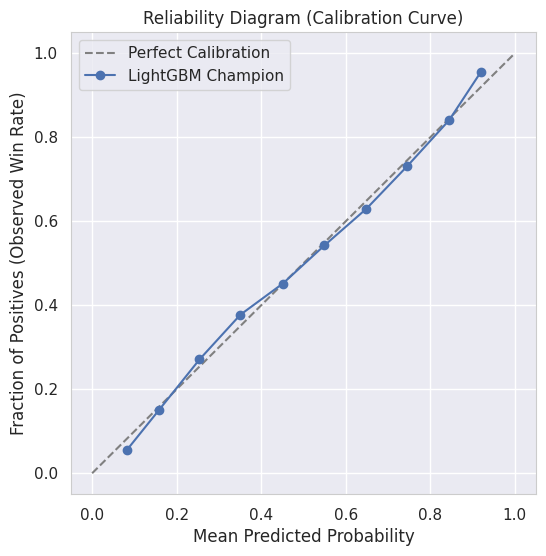

In [61]:
# Calibration diagnostics and Brier Score
# NOTE: calibration is a scikit-learn standard diagnostic imported as follows

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

#required inputs: 
# y_true: ground truth validation match targets
# y_prob: out-of-fold predicted probabilities for Player 1 Win
prob_true, prob_pred = calibration_curve(oof_true, oof_preds, n_bins=10)


# IMPLEMENTATION
#plot against ideal diagonal 
plt.figure(figsize=(6,6))
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Perfect Calibration')
plt.plot(prob_pred, prob_true, marker='o', label='LightGBM Champion')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Observed Win Rate)')
plt.title('Reliability Diagram (Calibration Curve)')
plt.legend()
plt.show()




#### 8.1.g. Brier Score vs Bookmaker Benchmark

In [62]:
# 1. Model Brier Score on OOF
model_brier = brier_score_loss(oof_true, oof_preds)


# 2. Bookmaker Brier Score (matches with available odds)
oof_bm = np.array(oof_benchmark, dtype=float)
valid_mask = ~np.isnan(oof_bm)
p1_bookmaker_prob = (oof_bm[valid_mask] + 1.0) / 2.0
bookmaker_brier = brier_score_loss(oof_true[valid_mask], p1_bookmaker_prob)

print(f"Model OOF Brier Score: {model_brier:.4f}")
print(f"Bookmaker OOF Brier Score: {bookmaker_brier:.4f}")


# Interpretability


#Holdout Evaluation (2024-2026) [predict on test_features.csv] -> report final Log-Loss, Brier Score, ROC-AUC

Model OOF Brier Score: 0.2144
Bookmaker OOF Brier Score: 0.2021


#### 8.1.h. Model Final Retraining
- instantiate the model with the best/winning parameters

In [63]:
# Final Retraining
# we instantiate the model with the best/winning parameters

# 1. Retrain on full historical data (2000-2023) with dynamic best parameters:
champion_lgb = LGBMClassifier(
    objective='binary', 
    metric='binary_logloss',
    learning_rate=0.03,
    num_leaves=int(best_config['num_leaves']),
    min_child_samples=int(best_config['min_child_samples']),
    max_depth=int(best_config.get('max_depth', -1)),
    reg_lambda=float(best_config.get('reg_lambda', 0.0)),
    colsample_bytree=float(best_config.get('colsample_bytree', 0.8)),
    subsample=0.8,
    subsample_freq=1,
    n_estimators=int(np.median(best_config['best_iterations'])),
    random_state=42
)

champion_lgb.fit(
    feature_matrix_X,
    target_variable_Y,
    categorical_feature=cat_features
)

[LightGBM] [Info] Number of positive: 30779, number of negative: 30781
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005912 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5619
[LightGBM] [Info] Number of data points in the train set: 61560, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499984 -> initscore=-0.000065
[LightGBM] [Info] Start training from score -0.000065
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, max_depth=7,
               metric='binary_logloss', min_child_samples=100, n_estimators=184,
               num_leaves=63, objective='binary', random_state=42,
               subsample=0.8, subsample_freq=1)

#### 8.1.i. Interpretability: extract the top 15 features by gain from final model

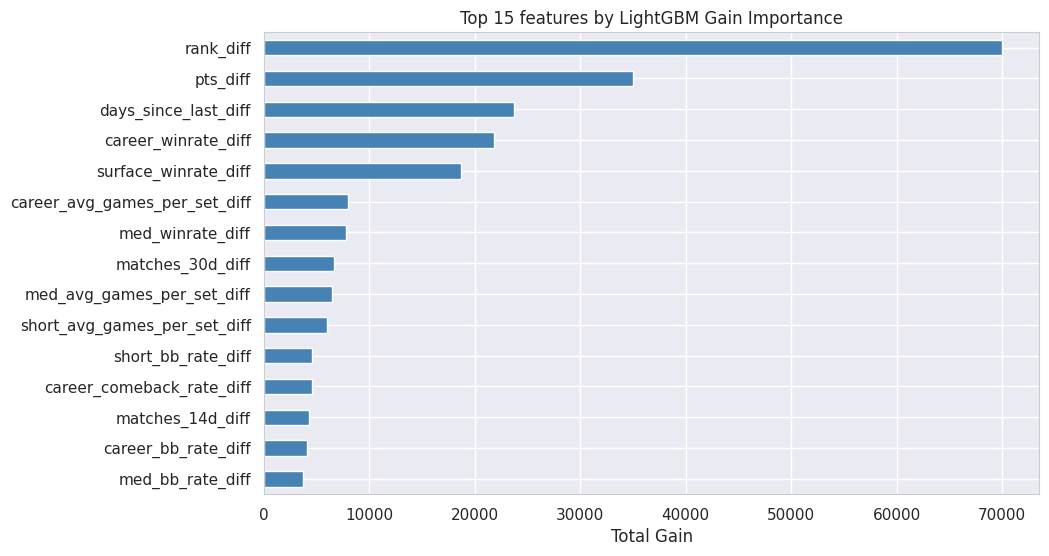

In [64]:
# TODO: interpretability
# 2. Extract and plot top 15 features by gain:
importance = pd.Series(
    champion_lgb.booster_.feature_importance(importance_type='gain'),
    index=feature_matrix_X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 features by LightGBM Gain Importance')
plt.xlabel('Total Gain')
plt.show()

#### 8.1.j. Holdout Evaluation (2024-2026 matches)
- We use the model to predict against `test_features.csv` -> report final `log-loss`, `Brier Score`, `ROC-AUC`

In [65]:
# TODO: evaluation
from sklearn.metrics import roc_auc_score, accuracy_score

# 1. Load/Prepare Test Set (identical partition)
test_df = pd.read_csv('/home/alfonsovsebolino/Documents/CSELEC1-ML/EDA/ATP_2000_2026/test_features.csv')
metadata_exclude = ['Date', 'Tournament', 'Series', 'Court', 'Surface', 'Round', 'Player_1', 'Player_2', 
                    'Winner', 'odds_diff', 'implied_prob_diff', 'target']

X_test = test_df.drop(columns=metadata_exclude)
y_test = test_df['target']

# 2. Predict Probabilities
y_test_pred = champion_lgb.predict_proba(X_test)[:, 1]

# 3. Compute Holdout Metrics
test_logloss = log_loss(y_test, y_test_pred)
test_brier = brier_score_loss(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred)
test_acc = accuracy_score(y_test, (y_test_pred >= 0.5).astype(int))

# 4. Bookmaker Benchmark on Test Set
bm_test = (test_df['implied_prob_diff'] + 1.0) / 2.0
valid_bm = test_df['implied_prob_diff'].notna()
bm_test_brier = brier_score_loss(y_test[valid_bm], bm_test[valid_bm])

# 5. Display Summary
print(f"--- 2024-2026 Test Holdout Metrics")
print(f"Log-Loss:   {test_logloss:.4f}")
print(f"Brier Score:    {test_brier:.4f} (Bookmaker: {bm_test_brier:.4f})")
print(f"ROC-AUC:    {test_auc:.4f}")
print(f"Accuracy:   {test_acc:.4f}")
    

--- 2024-2026 Test Holdout Metrics
Log-Loss:   0.6156
Brier Score:    0.2142 (Bookmaker: 0.2016)
ROC-AUC:    0.7167
Accuracy:   0.6538


### 8.2. Model 2: Regularized Logistic Regression (Linear Probabilistic Baseline)
In this section, we construct an empirical linear probabilistic baseline using L2-regularized `LogisticRegression` within an expanding-window chronological cross-validation framework. Continuous delta features are median-imputed and scaled via `RobustScaler`, categorical variables are one-hot encoded, and tournament format (`is_grand_slam`) is passed through as a binary indicator.

#### 8.2.a Data Partition and Expanding Window CV Setup 
- Drop match metadata (`Date`, `Tournament`, `Series`, `Court`, `Surface`, `Round`, `Player_1`, `Player_2`, `Winner`) and bookmaker odds (`odds_diff`, `implied_prob_diff`) from feature matrix $X$.
- Isolate `target` as target vector $y$.
- Isolate `implied_prob_diff` as external benchmark series.
- Construct 4 chronological expanding-window folds on `Date` (2000–2023) without row shuffling or future leakage.

In [66]:
# Strip metadata and bookmaker odds to build clean linear predictor matrix
metadata_exclude_lr = [
    'Date', 'Tournament', 'Series', 'Court', 'Surface', 'Round',
    'Player_1', 'Player_2', 'Winner', 'odds_diff', 'implied_prob_diff', 'target'
]

if 'train_df' not in globals():
    train_df = pd.read_csv('train_features.csv')

feature_matrix_X_lr = train_df.drop(columns=metadata_exclude_lr)
target_variable_Y_lr = train_df['target']
benchmark_prob_diff_lr = train_df['implied_prob_diff']

# Partition the 31 predictors: 28 continuous deltas, 2 categorical, 1 binary passthrough
cat_cols_lr = ['surface_encoded', 'series_encoded']
bin_cols_lr = ['is_grand_slam']
num_cols_lr = [c for c in feature_matrix_X_lr.columns if c not in cat_cols_lr and c not in bin_cols_lr]

print(f"Total LR Features: {feature_matrix_X_lr.shape[1]} (Numeric: {len(num_cols_lr)}, Categorical: {len(cat_cols_lr)}, Binary: {len(bin_cols_lr)})")
assert len(num_cols_lr) == 28, f"Expected 28 numeric features, got {len(num_cols_lr)}"
assert len(cat_cols_lr) == 2, f"Expected 2 categorical features, got {len(cat_cols_lr)}"
assert len(bin_cols_lr) == 1, f"Expected 1 binary feature, got {len(bin_cols_lr)}"

# 4 Expanding-window temporal CV-folds (2000–2023)
fold_windows_lr = [
    (2016, 2017, 2018),  # Fold 1: Train 2000–2016, Val 2017–2018
    (2018, 2019, 2020),  # Fold 2: Train 2000–2018, Val 2019–2020
    (2020, 2021, 2022),  # Fold 3: Train 2000–2020, Val 2021–2022
    (2022, 2023, 2023)   # Fold 4: Train 2000–2022, Val 2023
]

years_series = pd.to_datetime(train_df['Date']).dt.year
cv_splits_lr = [
    (
        np.where(years_series <= tr_end)[0],
        np.where((years_series >= v_start) & (years_series <= v_end))[0]
    )
    for tr_end, v_start, v_end in fold_windows_lr
]

for idx, (tr, val) in enumerate(cv_splits_lr, 1):
    print(f"Fold {idx}: Train={len(tr):,}, Val={len(val):,}")

Total LR Features: 31 (Numeric: 28, Categorical: 2, Binary: 1)
Fold 1: Train=45,182, Val=5,096
Fold 2: Train=50,278, Val=3,728
Fold 3: Train=54,006, Val=4,947
Fold 4: Train=58,953, Val=2,607


#### 8.2.b ColumnTransformer Preprocessing Pipeline 
- Impute continuous deltas with median strategy followed by `RobustScaler`.
- One-hot encode `surface_encoded` and `series_encoded` with `drop='first'`.
- Pass binary indicator `is_grand_slam` through.
- Wrap estimator in `sklearn.pipeline.Pipeline` with `LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)`.
- Verify output dimensionality and finiteness on dummy slice.

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Preprocessing pipeline
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), num_cols_lr),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_lr),
        ('bin', 'passthrough', bin_cols_lr)
    ]
)

# Sanity check fit-transform on dummy slice
dummy_transformed = preprocessor_lr.fit_transform(feature_matrix_X_lr.iloc[:100])
print(f"Dummy transformed matrix shape: {dummy_transformed.shape}")
assert np.all(np.isfinite(dummy_transformed)), "Non-finite values found in transformed dummy matrix"
print("ColumnTransformer pipeline sanity check passed.")

Dummy transformed matrix shape: (100, 28)
ColumnTransformer pipeline sanity check passed.


#### 8.2.c Cross-Validation & Regularization Parameter C Tuning 
- Search grid $C \in [10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1, 10, 100]$.
- Fit pipeline on each training fold and evaluate out-of-fold predictions on corresponding validation fold.
- Select optimal $C$ minimizing mean cross-validated `log_loss`.
- Log validation Brier score and accuracy per fold.

In [68]:
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score

c_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]
grid_cv_results = []

for C in c_grid:
    fold_losses = []
    fold_briers = []
    fold_accs = []
    
    for tr_idx, val_idx in cv_splits_lr:
        X_tr, y_tr = feature_matrix_X_lr.iloc[tr_idx], target_variable_Y_lr.iloc[tr_idx]
        X_val, y_val = feature_matrix_X_lr.iloc[val_idx], target_variable_Y_lr.iloc[val_idx]
        
        pipe = Pipeline([
            ('preprocessor', preprocessor_lr),
            ('classifier', LogisticRegression(
                C=C,
                penalty='l2',
                solver='lbfgs',
                max_iter=1000,
                random_state=42
            ))
        ])
        pipe.fit(X_tr, y_tr)
        val_probs = pipe.predict_proba(X_val)[:, 1]
        
        fold_losses.append(log_loss(y_val, val_probs))
        fold_briers.append(brier_score_loss(y_val, val_probs))
        fold_accs.append(accuracy_score(y_val, (val_probs >= 0.5).astype(int)))
        
    grid_cv_results.append({
        'C': C,
        'mean_log_loss': np.mean(fold_losses),
        'mean_brier': np.mean(fold_briers),
        'mean_accuracy': np.mean(fold_accs),
        'fold_losses': fold_losses,
        'fold_briers': fold_briers,
        'fold_accuracies': fold_accs
    })

cv_results_df = pd.DataFrame(grid_cv_results).sort_values('mean_log_loss')
best_lr_config = cv_results_df.iloc[0]
optimal_C = best_lr_config['C']

print(f"Optimal Regularization C: {optimal_C}")
print(cv_results_df[['C', 'mean_log_loss', 'mean_brier', 'mean_accuracy']].to_string(index=False))

Optimal Regularization C: 0.01
       C  mean_log_loss  mean_brier  mean_accuracy
  0.0100       0.619330    0.215607       0.651715
  0.0010       0.619352    0.215621       0.653153
  0.1000       0.619370    0.215624       0.651777
  1.0000       0.619381    0.215629       0.651991
100.0000       0.619382    0.215629       0.651859
 10.0000       0.619384    0.215630       0.651927
  0.0001       0.620490    0.216177       0.650066


#### 8.2.d Out-of-Fold Predictions & Calibration Diagnostics
- Collect out-of-fold probability predictions across all 4 CV folds using optimal $C$.
- Plot reliability diagram (calibration curve vs ideal diagonal).

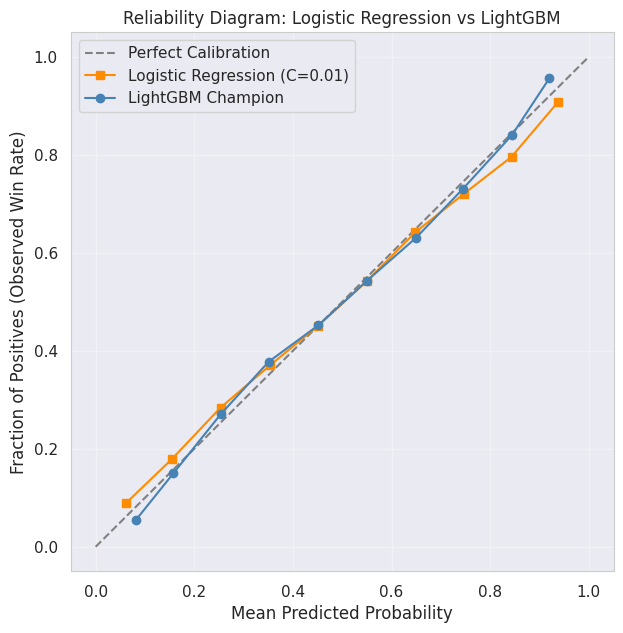

In [69]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

lr_oof_preds = []
lr_oof_true = []
lr_oof_benchmark = []

for tr_idx, val_idx in cv_splits_lr:
    X_tr, y_tr = feature_matrix_X_lr.iloc[tr_idx], target_variable_Y_lr.iloc[tr_idx]
    X_val, y_val = feature_matrix_X_lr.iloc[val_idx], target_variable_Y_lr.iloc[val_idx]
    
    pipe = Pipeline([
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(
            C=optimal_C,
            penalty='l2',
            solver='lbfgs',
            max_iter=1000,
            random_state=42
        ))
    ])
    pipe.fit(X_tr, y_tr)
    val_probs = pipe.predict_proba(X_val)[:, 1]
    
    lr_oof_preds.extend(val_probs)
    lr_oof_true.extend(y_val.values)
    lr_oof_benchmark.extend(benchmark_prob_diff_lr.iloc[val_idx].values)

lr_oof_preds = np.array(lr_oof_preds)
lr_oof_true = np.array(lr_oof_true)
lr_oof_benchmark = np.array(lr_oof_benchmark, dtype=float)

# Plot calibration curve
prob_true_lr, prob_pred_lr = calibration_curve(lr_oof_true, lr_oof_preds, n_bins=10)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.plot(prob_pred_lr, prob_true_lr, marker='s', color='darkorange', label=f'Logistic Regression (C={optimal_C})')
if 'oof_preds' in globals() and 'oof_true' in globals():
    prob_true_lgb, prob_pred_lgb = calibration_curve(oof_true, oof_preds, n_bins=10)
    plt.plot(prob_pred_lgb, prob_true_lgb, marker='o', color='steelblue', label='LightGBM Champion')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Observed Win Rate)')
plt.title('Reliability Diagram: Logistic Regression vs LightGBM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 8.2.e Brier Score Benchmark vs Bookmaker Baseline
Benchmark out-of-fold Brier score against market consensus implied win probabilities.

In [70]:
# Model OOF metrics
lr_oof_logloss = log_loss(lr_oof_true, lr_oof_preds)
lr_oof_brier = brier_score_loss(lr_oof_true, lr_oof_preds)
lr_oof_acc = accuracy_score(lr_oof_true, (lr_oof_preds >= 0.5).astype(int))

# Bookmaker implied odds benchmark (filtered for non-null matches)
valid_bm_oof = ~np.isnan(lr_oof_benchmark)
bm_oof_probs = (lr_oof_benchmark[valid_bm_oof] + 1.0) / 2.0
bm_oof_brier = brier_score_loss(lr_oof_true[valid_bm_oof], bm_oof_probs)
lr_oof_brier_bm_subset = brier_score_loss(lr_oof_true[valid_bm_oof], lr_oof_preds[valid_bm_oof])

print("=== Out-Of-Fold Evaluation Summary ===")
print(f"Logistic Regression OOF Log-Loss:    {lr_oof_logloss:.4f}")
print(f"Logistic Regression OOF Brier Score: {lr_oof_brier:.4f} (Odds subset: {lr_oof_brier_bm_subset:.4f})")
print(f"Bookmaker Consensus OOF Brier Score: {bm_oof_brier:.4f}")
print(f"Logistic Regression OOF Accuracy:    {lr_oof_acc:.4f}")

=== Out-Of-Fold Evaluation Summary ===
Logistic Regression OOF Log-Loss:    0.6195
Logistic Regression OOF Brier Score: 0.2156 (Odds subset: 0.2156)
Bookmaker Consensus OOF Brier Score: 0.2021
Logistic Regression OOF Accuracy:    0.6522


#### 8.2.f Full Dataset Retraining & Standardized Coefficient Interpretability
- Retrain pipeline on full historical dataset (2000–2023) using optimal $C$.
- Inspect top positive and negative standardized coefficients.

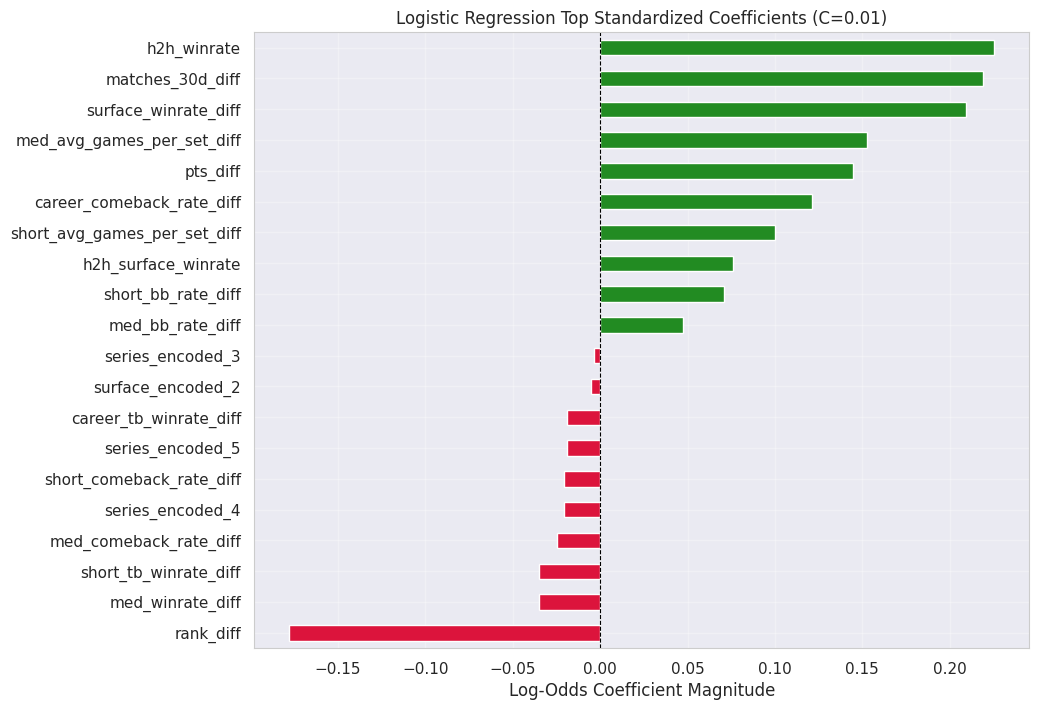

In [71]:
champion_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(
        C=optimal_C,
        penalty='l2',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])
champion_lr.fit(feature_matrix_X_lr, target_variable_Y_lr)

# Extract post-transformation feature names and model coefficients
ohe_names = champion_lr.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols_lr).tolist()
all_feature_names = num_cols_lr + ohe_names + bin_cols_lr
lr_coefs = champion_lr.named_steps['classifier'].coef_[0]

coef_series = pd.Series(lr_coefs, index=all_feature_names).sort_values()
top_coefs = pd.concat([coef_series.head(10), coef_series.tail(10)])

plt.figure(figsize=(10, 8))
colors = ['crimson' if c < 0 else 'forestgreen' for c in top_coefs.values]
top_coefs.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title(f'Logistic Regression Top Standardized Coefficients (C={optimal_C})')
plt.xlabel('Log-Odds Coefficient Magnitude')
plt.grid(True, alpha=0.3)
plt.show()

#### 8.2.g Holdout Evaluation on Test Matches (2024–2026)
Evaluate the retrained champion linear baseline on unseen future holdout matches from `test_features.csv`.

In [72]:
from sklearn.metrics import roc_auc_score

# Load and partition test holdout data
test_df_lr = pd.read_csv('/home/alfonsovsebolino/Documents/CSELEC1-ML/EDA/ATP_2000_2026/test_features.csv')
X_test_lr = test_df_lr.drop(columns=metadata_exclude_lr)
y_test_lr = test_df_lr['target']

# Generate test probability predictions
y_test_pred_lr = champion_lr.predict_proba(X_test_lr)[:, 1]

# Compute test holdout metrics
test_loss_lr = log_loss(y_test_lr, y_test_pred_lr)
test_brier_lr = brier_score_loss(y_test_lr, y_test_pred_lr)
test_auc_lr = roc_auc_score(y_test_lr, y_test_pred_lr)
test_acc_lr = accuracy_score(y_test_lr, (y_test_pred_lr >= 0.5).astype(int))

# Market benchmark on holdout set
bm_test_probs = (test_df_lr['implied_prob_diff'] + 1.0) / 2.0
valid_bm_test = test_df_lr['implied_prob_diff'].notna()
bm_test_brier_val = brier_score_loss(y_test_lr[valid_bm_test], bm_test_probs[valid_bm_test])
lr_test_brier_bm_subset = brier_score_loss(y_test_lr[valid_bm_test], y_test_pred_lr[valid_bm_test])

print("--- 2024–2026 Holdout Test Evaluation: Logistic Regression Baseline ---")
print(f"Log-Loss:        {test_loss_lr:.4f}")
print(f"Brier Score:     {test_brier_lr:.4f} (Odds subset: {lr_test_brier_bm_subset:.4f}, Bookmaker: {bm_test_brier_val:.4f})")
print(f"ROC-AUC:         {test_auc_lr:.4f}")
print(f"Accuracy:        {test_acc_lr:.4f}")

--- 2024–2026 Holdout Test Evaluation: Logistic Regression Baseline ---
Log-Loss:        0.6205
Brier Score:     0.2159 (Odds subset: 0.2162, Bookmaker: 0.2016)
ROC-AUC:         0.7120
Accuracy:        0.6494


#### 8.2.h ROC / AUC Visualizations
Plot Receiver Operating Characteristic (ROC) curves comparing out-of-fold and holdout performance against the LightGBM champion and random guessing.

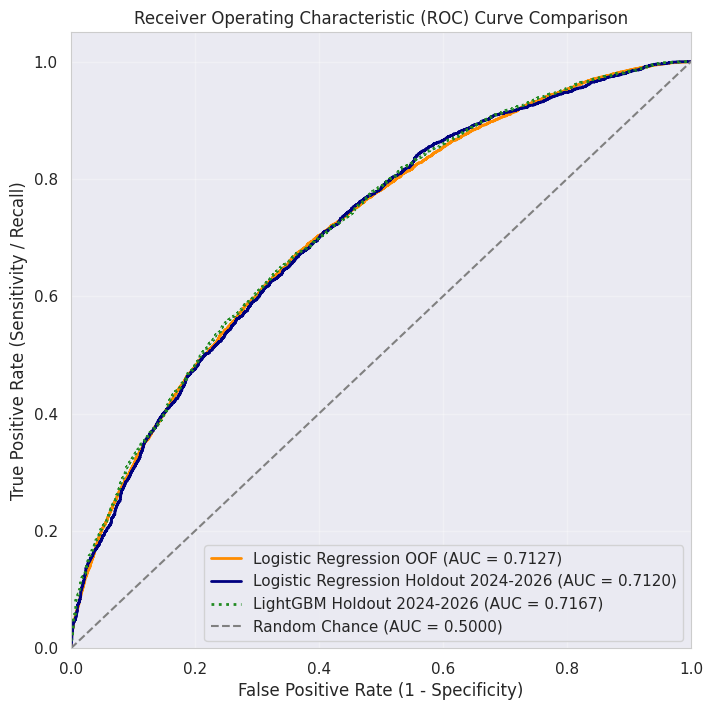

In [73]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curves
fpr_lr_oof, tpr_lr_oof, _ = roc_curve(lr_oof_true, lr_oof_preds)
auc_lr_oof = auc(fpr_lr_oof, tpr_lr_oof)

fpr_lr_test, tpr_lr_test, _ = roc_curve(y_test_lr, y_test_pred_lr)
auc_lr_test = auc(fpr_lr_test, tpr_lr_test)

plt.figure(figsize=(8, 8))
plt.plot(fpr_lr_oof, tpr_lr_oof, color='darkorange', lw=2,
        label=f'Logistic Regression OOF (AUC = {auc_lr_oof:.4f})')
plt.plot(fpr_lr_test, tpr_lr_test, color='navy', lw=2,
        label=f'Logistic Regression Holdout 2024-2026 (AUC = {auc_lr_test:.4f})')

if 'y_test' in globals() and 'y_test_pred' in globals():
    fpr_lgb_test, tpr_lgb_test, _ = roc_curve(y_test, y_test_pred)
    auc_lgb_test = auc(fpr_lgb_test, tpr_lgb_test)
    plt.plot(fpr_lgb_test, tpr_lgb_test, color='forestgreen', lw=2, linestyle=':',
            label=f'LightGBM Holdout 2024-2026 (AUC = {auc_lgb_test:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Chance (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right', frameon=True)
plt.grid(True, alpha=0.3)
plt.show()

### 8.3. Comprehensive Model Comparison: LightGBM vs Logistic Regression
Benchmark table summarizing probabilistic calibration and holdout discrimination across both models.

In [74]:
summary_data = [
    {
        'Model': 'Logistic Regression (L2)',
        'OOF Log-Loss': f"{lr_oof_logloss:.4f}",
        'OOF Brier Score': f"{lr_oof_brier:.4f}",
        'Test Log-Loss': f"{test_loss_lr:.4f}",
        'Test Brier Score': f"{test_brier_lr:.4f}",
        'Test ROC-AUC': f"{test_auc_lr:.4f}",
        'Test Accuracy': f"{test_acc_lr:.4f}"
    }
]

if 'test_logloss' in globals() and 'test_brier' in globals() and 'test_auc' in globals():
    summary_data.insert(0, {
        'Model': 'LightGBM Champion',
        'OOF Log-Loss': f"{results_df.iloc[0]['mean_logloss']:.4f}" if 'results_df' in globals() else "N/A",
        'OOF Brier Score': f"{model_brier:.4f}" if 'model_brier' in globals() else "N/A",
        'Test Log-Loss': f"{test_logloss:.4f}",
        'Test Brier Score': f"{test_brier:.4f}",
        'Test ROC-AUC': f"{test_auc:.4f}",
        'Test Accuracy': f"{test_acc:.4f}"
    })

comparison_table = pd.DataFrame(summary_data)
print(comparison_table.to_string(index=False))

                   Model OOF Log-Loss OOF Brier Score Test Log-Loss Test Brier Score Test ROC-AUC Test Accuracy
       LightGBM Champion       0.6152          0.2144        0.6156           0.2142       0.7167        0.6538
Logistic Regression (L2)       0.6195          0.2156        0.6205           0.2159       0.7120        0.6494


## Phase 9: Interactive Match Inference & Historical Backtracker Widget



### 9.1. Inference Engine & State Snapshot Extractor

In [8]:
# Phase 9.1: Inference Engine Helper & State Extractor
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd
import numpy as np

# 1. Define exact 31 model training feature columns (strictly excluding odds/metadata)
if 'feature_matrix_X' in globals():
    model_features = feature_matrix_X.columns.tolist()
else:
    meta_excl = ['Date', 'Tournament', 'Series', 'Court', 'Surface', 'Round',
                'Player_1', 'Player_2', 'Winner', 'odds_diff', 'implied_prob_diff', 'target']
    source_cols = selected_features if 'selected_features' in globals() else df.columns.tolist()
    model_features = [c for c in source_cols if c not in meta_excl]

# 2. Extract player feature state directly from feature-engineered df & long_df
feat_list = [
    "short_winrate", "short_tb_winrate", "short_comeback_rate", "short_bb_rate", "short_avg_games_per_set",
    "med_winrate", "med_tb_winrate", "med_comeback_rate", "med_bb_rate", "med_avg_games_per_set", "med_ret_freq",
    "career_winrate", "career_tb_winrate", "career_comeback_rate", "career_bb_rate", "career_avg_games_per_set", "career_ret_freq",
    "surface_winrate", "days_since_last", "matches_14d", "matches_30d", "form_divergence"
]

# Unpivot match-level player columns from df into player history
p1_cols = {'Player_1': 'player', 'Rank_1': 'Rank', 'Pts_1': 'Pts', **{f'{f}_1': f for f in feat_list if f'{f}_1' in df.columns}}
p2_cols = {'Player_2': 'player', 'Rank_2': 'Rank', 'Pts_2': 'Pts', **{f'{f}_2': f for f in feat_list if f'{f}_2' in df.columns}}

p1_df = df[['Date'] + list(p1_cols.keys())].rename(columns=p1_cols)
p2_df = df[['Date'] + list(p2_cols.keys())].rename(columns=p2_cols)
all_player_matches = pd.concat([p1_df, p2_df], ignore_index=True).sort_values('Date')
latest_player_state = all_player_matches.groupby('player').last().to_dict('index')

# Surface career win rate lookup map
if 'long_df' in globals():
    player_surface_wr = long_df.groupby(['player', 'Surface'])['surface_winrate'].last().to_dict()
else:
    player_surface_wr = {}

# Dynamic H2H Lookup
def get_h2h_stats(p1, p2, surface, cutoff_date=None):
    h2h_sub = df[((df['Player_1'] == p1) & (df['Player_2'] == p2)) | ((df['Player_1'] == p2) & (df['Player_2'] == p1))]
    if cutoff_date is not None:
        h2h_sub = h2h_sub[h2h_sub['Date'] < cutoff_date]
    if len(h2h_sub) == 0:
        return {'h2h_winrate': 0.5, 'h2h_match_count': 0, 'h2h_surface_winrate': 0.5, 'h2h_surface_count': 0}
    p1_wins = (h2h_sub['Winner'] == p1).sum()
    total = len(h2h_sub)
    surf_sub = h2h_sub[h2h_sub['Surface'] == surface]
    surf_total = len(surf_sub)
    surf_wins = (surf_sub['Winner'] == p1).sum() if surf_total > 0 else 0
    return {
        'h2h_winrate': p1_wins / total,
        'h2h_match_count': total,
        'h2h_surface_winrate': (surf_wins / surf_total) if surf_total > 0 else 0.5,
        'h2h_surface_count': surf_total
    }

# 31-Feature Vector Builder
def build_match_features(p1, p2, surface, series, target_date=None):
    s1 = latest_player_state.get(p1, {'Rank': 500, 'Pts': 0, 'form_divergence': 0.0, 'matches_14d': 0, 'matches_30d': 0, 'days_since_last': 30, 'career_winrate': 0.5})
    s2 = latest_player_state.get(p2, {'Rank': 500, 'Pts': 0, 'form_divergence': 0.0, 'matches_14d': 0, 'matches_30d': 0, 'days_since_last': 30, 'career_winrate': 0.5})
    
    p1_swr = player_surface_wr.get((p1, surface), s1.get('career_winrate', 0.5))
    p2_swr = player_surface_wr.get((p2, surface), s2.get('career_winrate', 0.5))
    h2h = get_h2h_stats(p1, p2, surface, cutoff_date=target_date)
    
    # Consistent categorical encoding
    if 'le_surf' in globals() and surface in le_surf.classes_:
        surf_code = int(le_surf.transform([surface])[0])
    else:
        surf_code = {'Carpet': 0, 'Clay': 1, 'Grass': 2, 'Hard': 3}.get(surface, 3)
        
    if 'le_series' in globals() and series in le_series.classes_:
        ser_code = int(le_series.transform([series])[0])
    else:
        ser_code = {'ATP250': 0, 'ATP500': 1, 'Grand Slam': 2, 'International': 3,
                    'International Gold': 4, 'Masters': 5, 'Masters 1000': 6, 'Masters Cup': 7}.get(series, 2)
    
    row = {
        'rank_diff': float(s1.get('Rank', 500) - s2.get('Rank', 500)),
        'pts_diff': float(s1.get('Pts', 0) - s2.get('Pts', 0)),
        'short_winrate_diff': float(s1.get('short_winrate', 0.5) - s2.get('short_winrate', 0.5)),
        'short_tb_winrate_diff': float(s1.get('short_tb_winrate', 0.5) - s2.get('short_tb_winrate', 0.5)),
        'short_comeback_rate_diff': float(s1.get('short_comeback_rate', 0.0) - s2.get('short_comeback_rate', 0.0)),
        'short_bb_rate_diff': float(s1.get('short_bb_rate', 0.0) - s2.get('short_bb_rate', 0.0)),
        'short_avg_games_per_set_diff': float(s1.get('short_avg_games_per_set', 4.9) - s2.get('short_avg_games_per_set', 4.9)),
        'med_winrate_diff': float(s1.get('med_winrate', 0.5) - s2.get('med_winrate', 0.5)),
        'med_tb_winrate_diff': float(s1.get('med_tb_winrate', 0.5) - s2.get('med_tb_winrate', 0.5)),
        'med_comeback_rate_diff': float(s1.get('med_comeback_rate', 0.0) - s2.get('med_comeback_rate', 0.0)),
        'med_bb_rate_diff': float(s1.get('med_bb_rate', 0.0) - s2.get('med_bb_rate', 0.0)),
        'med_avg_games_per_set_diff': float(s1.get('med_avg_games_per_set', 4.9) - s2.get('med_avg_games_per_set', 4.9)),
        'med_ret_freq_diff': float(s1.get('med_ret_freq', 0.0) - s2.get('med_ret_freq', 0.0)),
        'career_winrate_diff': float(s1.get('career_winrate', 0.5) - s2.get('career_winrate', 0.5)),
        'career_tb_winrate_diff': float(s1.get('career_tb_winrate', 0.5) - s2.get('career_tb_winrate', 0.5)),
        'career_comeback_rate_diff': float(s1.get('career_comeback_rate', 0.0) - s2.get('career_comeback_rate', 0.0)),
        'career_bb_rate_diff': float(s1.get('career_bb_rate', 0.0) - s2.get('career_bb_rate', 0.0)),
        'career_avg_games_per_set_diff': float(s1.get('career_avg_games_per_set', 4.9) - s2.get('career_avg_games_per_set', 4.9)),
        'career_ret_freq_diff': float(s1.get('career_ret_freq', 0.0) - s2.get('career_ret_freq', 0.0)),
        'surface_winrate_diff': float(p1_swr - p2_swr),
        'days_since_last_diff': float(s1.get('days_since_last', 14) - s2.get('days_since_last', 14)),
        'matches_14d_diff': float(s1.get('matches_14d', 0) - s2.get('matches_14d', 0)),
        'matches_30d_diff': float(s1.get('matches_30d', 0) - s2.get('matches_30d', 0)),
        'form_divergence_diff': float(s1.get('form_divergence', 0.0) - s2.get('form_divergence', 0.0)),
        'h2h_winrate': float(h2h['h2h_winrate']),
        'h2h_match_count': float(h2h['h2h_match_count']),
        'h2h_surface_winrate': float(h2h['h2h_surface_winrate']),
        'h2h_surface_count': float(h2h['h2h_surface_count']),
        'surface_encoded': surf_code,
        'series_encoded': ser_code,
        'is_grand_slam': 1 if series == 'Grand Slam' else 0
    }
    return pd.DataFrame([row])[model_features]



KeyError: "['Rank_1', 'Pts_1'] not in index"

#### 9.2 Export Inference Bundle (Run Once to Persist to Disk/Workspace)
- Serializes `champion_lgb`, `champion_lr`, encoders, and player snapshots into `atp_inference_bundle.joblib`

In [6]:
import joblib

bundle = {
    'champion_lgb': champion_lgb,
    'champion_lr' : champion_lr, 
    'model_features': model_features,
    'latest_player_state': latest_player_state, 
    'player_surface_wr': player_surface_wr, 
    'le_surf': le_surf if 'le_surf' in globals() else None,
    'le_series': le_series if 'le_series' in globals() else None
}

joblib.dump(bundle, 'atp_inference_bundle.joblib', compress=3)
print("Saved atp_inference_bundle.joblibe")

Saved atp_inference_bundle.joblibe


### 9.3. Rich HTML Dashboard Card Generator

In [5]:
# Function: feature-rich dashboard card generator (parameterized)
def render_inference_card(p1, p2, surface, series, prob_lgb, prob_lr, key_stats, bm_prob=None, actual_winner=None):
    p1_lgb, p2_lgb = prob_lgb * 100, (1 - prob_lgb) * 100
    p1_lr, p2_lr = prob_lr * 100, (1 - prob_lr) * 100
    pred_winner = p1 if p1_lgb >= 50 else p2
    
    bm_html = ""
    if bm_prob is not None and not np.isnan(bm_prob):
        p1_bm, p2_bm = bm_prob * 100, (1 - bm_prob) * 100
        bm_html = f"""
        <div style="margin-top: 10px;">
            <div style="display:flex; justify-content:space-between; font-size:12px; color:#94a3b8; margin-bottom:3px;">
                <span>Bookmaker Implied: <b>{p1_bm:.1f}%</b></span>
                <span><b>{p2_bm:.1f}%</b></span>
            </div>
            <div style="background:#334155; border-radius:6px; height:8px; display:flex; overflow:hidden;">
                <div style="background:#f59e0b; width:{p1_bm}%;"></div>
                <div style="background:#64748b; width:{p2_bm}%;"></div>
            </div>
        </div>
        """

    outcome_html = ""
    if actual_winner:
        is_hit = (actual_winner == pred_winner)
        color = "#10b981" if is_hit else "#ef4444"
        badge = "CORRECT" if is_hit else "MISS"
        outcome_html = f"""
        <div style="display:inline-block; padding:3px 8px; border-radius:4px; font-size:11px; font-weight:700; background:{color}22; color:{color}; border:1px solid {color}; margin-left:8px;">
            {badge}: Winner = {actual_winner}
        </div>
        """

    html = f"""
    <div style="background:#1e293b; color:#f8fafc; border-radius:12px; padding:18px; font-family:sans-serif; max-width:680px; box-shadow:0 4px 12px rgba(0,0,0,0.3); border:1px solid #334155; margin-top:10px;">
        <div style="display:flex; justify-content:space-between; align-items:center; border-bottom:1px solid #334155; padding-bottom:10px; margin-bottom:12px;">
            <div>
                <span style="font-size:18px; font-weight:700; color:#38bdf8;">{p1}</span>
                <span style="font-size:14px; color:#64748b; margin:0 6px;">vs</span>
                <span style="font-size:18px; font-weight:700; color:#cbd5e1;">{p2}</span>
                {outcome_html}
            </div>
            <div style="font-size:11px; color:#94a3b8; background:#0f172a; padding:4px 10px; border-radius:6px; border:1px solid #334155;">
                {surface} • {series}
            </div>
        </div>

        <div style="margin-bottom:12px;">
            <div style="display:flex; justify-content:space-between; font-size:13px; font-weight:600; margin-bottom:4px;">
                <span>LightGBM Champion: <span style="color:#38bdf8;">{p1_lgb:.1f}%</span></span>
                <span style="color:#94a3b8;">{p2_lgb:.1f}%</span>
            </div>
            <div style="background:#334155; border-radius:6px; height:12px; display:flex; overflow:hidden;">
                <div style="background:linear-gradient(90deg, #0284c7, #38bdf8); width:{p1_lgb}%;"></div>
                <div style="background:#475569; width:{p2_lgb}%;"></div>
            </div>
        </div>

        <div style="margin-bottom:12px;">
            <div style="display:flex; justify-content:space-between; font-size:13px; font-weight:600; margin-bottom:4px;">
                <span>Logistic Regression: <span style="color:#a855f7;">{p1_lr:.1f}%</span></span>
                <span style="color:#94a3b8;">{p2_lr:.1f}%</span>
            </div>
            <div style="background:#334155; border-radius:6px; height:10px; display:flex; overflow:hidden;">
                <div style="background:linear-gradient(90deg, #7e22ce, #a855f7); width:{p1_lr}%;"></div>
                <div style="background:#475569; width:{p2_lr}%;"></div>
            </div>
        </div>

        {bm_html}

        <div style="display:grid; grid-template-columns: repeat(5, 1fr); gap:8px; margin-top:14px; background:#0f172a; padding:10px; border-radius:8px; border:1px solid #334155; text-align:center; font-size:11px;">
            <div>
                <div style="color:#64748b;">Rank Δ</div>
                <div style="font-weight:700; color:{'#10b981' if key_stats['rank_diff'] <= 0 else '#ef4444'};">{key_stats['rank_diff']:+.0f}</div>
            </div>
            <div>
                <div style="color:#64748b;">Surface WR Δ</div>
                <div style="font-weight:700; color:{'#10b981' if key_stats['surface_winrate_diff'] >= 0 else '#ef4444'};">{key_stats['surface_winrate_diff']*100:+.1f}%</div>
            </div>
            <div>
                <div style="color:#64748b;">Form Div Δ</div>
                <div style="font-weight:700; color:{'#10b981' if key_stats['form_divergence_diff'] >= 0 else '#ef4444'};">{key_stats['form_divergence_diff']:+.2f}</div>
            </div>
            <div>
                <div style="color:#64748b;">Fatigue 14d Δ</div>
                <div style="font-weight:700;">{key_stats['matches_14d_diff']:+.0f} m</div>
            </div>
            <div>
                <div style="color:#64748b;">H2H Record</div>
                <div style="font-weight:700; color:#38bdf8;">{key_stats['h2h_p1_wins']} - {key_stats['h2h_p2_wins']}</div>
            </div>
        </div>
    </div>
    """
    return HTML(html)



### 9.4. Interactive Two-Tab Widget Interface

In [9]:
# Phase 9.4: Interactive ipywidgets Two-Tab Interface
active_players = sorted([p for p, s in latest_player_state.items() if pd.to_datetime(s.get('Date', '2000-01-01')).year >= 2023])
all_players = sorted(list(latest_player_state.keys()))

# --- Tab 1: Upcoming Match Predictor ---
p1_dd = widgets.Dropdown(options=active_players, value=active_players[0] if active_players else None, description="Player 1:", layout=widgets.Layout(width='320px'))
swap_btn = widgets.Button(description="⇄ Swap", tooltip="Audit inversion symmetry", layout=widgets.Layout(width='80px'))
p2_dd = widgets.Dropdown(options=active_players, value=active_players[1] if len(active_players) > 1 else None, description="Player 2:", layout=widgets.Layout(width='320px'))
surf_dd = widgets.Dropdown(options=['Hard', 'Clay', 'Grass', 'Carpet'], value='Hard', description="Surface:", layout=widgets.Layout(width='200px'))
series_dd = widgets.Dropdown(options=['Grand Slam', 'Masters', 'International', 'International Gold'], value='Grand Slam', description="Series:", layout=widgets.Layout(width='240px'))
all_cb = widgets.Checkbox(value=False, description="Unlock Full Historical Roster (2000–2026)")
predict_btn = widgets.Button(description="Predict Matchup", button_style='primary', icon='bolt')
out_tab1 = widgets.Output()

def on_swap(b):
    cur_p1, cur_p2 = p1_dd.value, p2_dd.value
    p1_dd.value, p2_dd.value = cur_p2, cur_p1

swap_btn.on_click(on_swap)

def on_toggle_all(change):
    pool = all_players if change['new'] else active_players
    p1_val, p2_val = p1_dd.value, p2_dd.value
    p1_dd.options = pool
    p2_dd.options = pool
    if p1_val in pool: p1_dd.value = p1_val
    if p2_val in pool: p2_dd.value = p2_val

all_cb.observe(on_toggle_all, names='value')

def on_predict_upcoming(b):
    with out_tab1:
        out_tab1.clear_output()
        p1, p2 = p1_dd.value, p2_dd.value
        surf, ser = surf_dd.value, series_dd.value
        X_vec = build_match_features(p1, p2, surf, ser)
        prob_lgb = champion_lgb.predict_proba(X_vec)[0, 1]
        prob_lr = champion_lr.predict_proba(X_vec)[0, 1]
        
        h2h_data = get_h2h_stats(p1, p2, surf)
        key_stats = {
            'rank_diff': X_vec['rank_diff'].iloc[0],
            'surface_winrate_diff': X_vec['surface_winrate_diff'].iloc[0],
            'form_divergence_diff': X_vec['form_divergence_diff'].iloc[0],
            'matches_14d_diff': X_vec['matches_14d_diff'].iloc[0],
            'h2h_p1_wins': int(round(h2h_data['h2h_winrate'] * h2h_data['h2h_match_count'])),
            'h2h_p2_wins': int(h2h_data['h2h_match_count'] - round(h2h_data['h2h_winrate'] * h2h_data['h2h_match_count']))
        }
        display(render_inference_card(p1, p2, surf, ser, prob_lgb, prob_lr, key_stats))

predict_btn.on_click(on_predict_upcoming)

box_tab1 = widgets.VBox([
    all_cb,
    widgets.HBox([p1_dd, swap_btn, p2_dd]),
    widgets.HBox([surf_dd, series_dd, predict_btn]),
    out_tab1
])

# --- Tab 2: Historical Match Backtracker ---
split_dd = widgets.Dropdown(options=['Holdout Test (2024–2026)', 'Full Dataset (2000–2026)'], value='Holdout Test (2024–2026)', description="Split:", layout=widgets.Layout(width='320px'))
tourn_dd = widgets.Dropdown(description="Tournament:", layout=widgets.Layout(width='320px'))
match_dd = widgets.Dropdown(description="Matchup:", layout=widgets.Layout(width='450px'))
backtrack_btn = widgets.Button(description="Inspect & Backtrack", button_style='info', icon='search')
out_tab2 = widgets.Output()

def get_current_df():
    return test_df if 'Holdout' in split_dd.value else df

def update_tournaments(*args):
    cdf = get_current_df()
    tourns = sorted(cdf['Tournament'].dropna().unique())
    tourn_dd.options = tourns
    if tourns: tourn_dd.value = tourns[0]

def update_matches(*args):
    cdf = get_current_df()
    m_sub = cdf[cdf['Tournament'] == tourn_dd.value]
    options = []
    for idx, row in m_sub.iterrows():
        d_str = str(row['Date'])[:10]
        options.append((f"[{d_str} | {row.get('Round', '')}] {row['Player_1']} vs {row['Player_2']} (Winner: {row['Winner']})", idx))
    match_dd.options = options

split_dd.observe(update_tournaments, names='value')
tourn_dd.observe(update_matches, names='value')
update_tournaments()
update_matches()

def on_backtrack(b):
    with out_tab2:
        out_tab2.clear_output()
        cdf = get_current_df()
        idx = match_dd.value
        if idx is None or idx not in cdf.index: return
        row = cdf.loc[idx]
        
        p1, p2 = row['Player_1'], row['Player_2']
        surf, ser = row['Surface'], row['Series']
        X_vec = cdf.loc[[idx], model_features].apply(pd.to_numeric)
        
        prob_lgb = champion_lgb.predict_proba(X_vec)[0, 1]
        prob_lr = champion_lr.predict_proba(X_vec)[0, 1]
        
        bm_prob = None
        if 'implied_prob_diff' in row and pd.notnull(row['implied_prob_diff']):
            bm_prob = (row['implied_prob_diff'] + 1.0) / 2.0
            
        h2h_data = get_h2h_stats(p1, p2, surf, cutoff_date=row['Date'])
        key_stats = {
            'rank_diff': row['rank_diff'],
            'surface_winrate_diff': row['surface_winrate_diff'],
            'form_divergence_diff': row['form_divergence_diff'],
            'matches_14d_diff': row['matches_14d_diff'],
            'h2h_p1_wins': int(round(h2h_data['h2h_winrate'] * h2h_data['h2h_match_count'])),
            'h2h_p2_wins': int(h2h_data['h2h_match_count'] - round(h2h_data['h2h_winrate'] * h2h_data['h2h_match_count']))
        }
        display(render_inference_card(p1, p2, surf, ser, prob_lgb, prob_lr, key_stats, bm_prob=bm_prob, actual_winner=row['Winner']))

backtrack_btn.on_click(on_backtrack)

box_tab2 = widgets.VBox([
    widgets.HBox([split_dd, tourn_dd]),
    widgets.HBox([match_dd, backtrack_btn]),
    out_tab2
])

# --- Assemble Tabbed Display ---
tabs = widgets.Tab(children=[box_tab1, box_tab2])
tabs.set_title(0, 'Upcoming Match Inference')
tabs.set_title(1, 'Historical Match Backtracker')
display(tabs)


### 9.0 Fast-boot Inference Loader (Post-Restart Cold Start)
- Loads persisted model pipelines and player state in <0.3s
- Run this cell when reopening notebook to skip upstream(time-consuming) cells

In [2]:
# download joblib model configuration from colab server


try: 
    from google.colab import files
    files.download('atp_inference_bundle.joblib')
    print(" Download triggered via Google Colab.")
except ImportError:
    print("Local environment detected: bundle already accessible at ./atp_inference_bundle.joblib")

Local environment detected: bundle already accessible at ./atp_inference_bundle.joblib


In [3]:
import joblib, pandas as pd, numpy as np

# [COMPATIBILITY SHIM FOR SKLEARN 1.6 -> 1.9 UNPICKLING]
import sklearn.compose._column_transformer
if not hasattr(sklearn.compose._column_transformer, '_RemainderColsList'):
    class _RemainderColsList(list): pass
    sklearn.compose._column_transformer._RemainderColsList = _RemainderColsList

# Load persisted weights, pipelines, and state map (<0.3s)
bundle = joblib.load('atp_inference_bundle.joblib')
champion_lgb = bundle['champion_lgb']
champion_lr = bundle['champion_lr']
model_features = bundle['model_features']
latest_player_state = bundle['latest_player_state']
player_surface_wr = bundle['player_surface_wr']
le_surf = bundle['le_surf']
le_series = bundle.get('le_series', None)

# Fix imputer dtype attribute across sklearn versions
pre = champion_lr.named_steps['preprocessor']
for name, trans, cols in pre.transformers_:
    if hasattr(trans, 'named_steps'):
        for step_name, step in trans.named_steps.items():
            if hasattr(step, '_fit_dtype') and not hasattr(step, '_fill_dtype'):
                step._fill_dtype = step._fit_dtype

# Historical data for backtracker
test_df = pd.read_csv('test_features.csv')
df = test_df

# Self-contained H2H and Feature Vector Helpers
def get_h2h_stats(p1, p2, surface, cutoff_date=None):
    h2h_sub = df[((df['Player_1'] == p1) & (df['Player_2'] == p2)) | ((df['Player_1'] == p2) & (df['Player_2'] == p1))]
    if cutoff_date is not None:
        h2h_sub = h2h_sub[h2h_sub['Date'] < cutoff_date]
    if len(h2h_sub) == 0:
        return {'h2h_winrate': 0.5, 'h2h_match_count': 0, 'h2h_surface_winrate': 0.5, 'h2h_surface_count': 0}
    p1_wins = (h2h_sub['Winner'] == p1).sum()
    total = len(h2h_sub)
    surf_sub = h2h_sub[h2h_sub['Surface'] == surface]
    surf_total = len(surf_sub)
    surf_wins = (surf_sub['Winner'] == p1).sum() if surf_total > 0 else 0
    return {
        'h2h_winrate': p1_wins / total,
        'h2h_match_count': total,
        'h2h_surface_winrate': (surf_wins / surf_total) if surf_total > 0 else 0.5,
        'h2h_surface_count': surf_total
    }

def build_match_features(p1, p2, surface, series, target_date=None):
    s1 = latest_player_state.get(p1, {'Rank': 500, 'Pts': 0, 'form_divergence': 0.0, 'matches_14d': 0, 'matches_30d': 0, 'days_since_last': 30, 'career_winrate': 0.5})
    s2 = latest_player_state.get(p2, {'Rank': 500, 'Pts': 0, 'form_divergence': 0.0, 'matches_14d': 0, 'matches_30d': 0, 'days_since_last': 30, 'career_winrate': 0.5})
    p1_swr = player_surface_wr.get((p1, surface), s1.get('career_winrate', 0.5))
    p2_swr = player_surface_wr.get((p2, surface), s2.get('career_winrate', 0.5))
    h2h = get_h2h_stats(p1, p2, surface, cutoff_date=target_date)
    
    surf_code = int(le_surf.transform([surface])[0]) if hasattr(le_surf, 'classes_') and surface in le_surf.classes_ else {'Carpet': 0, 'Clay': 1, 'Grass': 2, 'Hard': 3}.get(surface, 3)
    ser_code = int(le_series.transform([series])[0]) if hasattr(le_series, 'classes_') and series in le_series.classes_ else {'ATP250': 0, 'ATP500': 1, 'Grand Slam': 2, 'International': 3, 'International Gold': 4, 'Masters': 5, 'Masters 1000': 6, 'Masters Cup': 7}.get(series, 2)
    
    row = {
        'rank_diff': float(s1.get('Rank', 500) - s2.get('Rank', 500)),
        'pts_diff': float(s1.get('Pts', 0) - s2.get('Pts', 0)),
        'short_winrate_diff': float(s1.get('short_winrate', 0.5) - s2.get('short_winrate', 0.5)),
        'short_tb_winrate_diff': float(s1.get('short_tb_winrate', 0.5) - s2.get('short_tb_winrate', 0.5)),
        'short_comeback_rate_diff': float(s1.get('short_comeback_rate', 0.0) - s2.get('short_comeback_rate', 0.0)),
        'short_bb_rate_diff': float(s1.get('short_bb_rate', 0.0) - s2.get('short_bb_rate', 0.0)),
        'short_avg_games_per_set_diff': float(s1.get('short_avg_games_per_set', 4.9) - s2.get('short_avg_games_per_set', 4.9)),
        'med_winrate_diff': float(s1.get('med_winrate', 0.5) - s2.get('med_winrate', 0.5)),
        'med_tb_winrate_diff': float(s1.get('med_tb_winrate', 0.5) - s2.get('med_tb_winrate', 0.5)),
        'med_comeback_rate_diff': float(s1.get('med_comeback_rate', 0.0) - s2.get('med_comeback_rate', 0.0)),
        'med_bb_rate_diff': float(s1.get('med_bb_rate', 0.0) - s2.get('med_bb_rate', 0.0)),
        'med_avg_games_per_set_diff': float(s1.get('med_avg_games_per_set', 4.9) - s2.get('med_avg_games_per_set', 4.9)),
        'med_ret_freq_diff': float(s1.get('med_ret_freq', 0.0) - s2.get('med_ret_freq', 0.0)),
        'career_winrate_diff': float(s1.get('career_winrate', 0.5) - s2.get('career_winrate', 0.5)),
        'career_tb_winrate_diff': float(s1.get('career_tb_winrate', 0.5) - s2.get('career_tb_winrate', 0.5)),
        'career_comeback_rate_diff': float(s1.get('career_comeback_rate', 0.0) - s2.get('career_comeback_rate', 0.0)),
        'career_bb_rate_diff': float(s1.get('career_bb_rate', 0.0) - s2.get('career_bb_rate', 0.0)),
        'career_avg_games_per_set_diff': float(s1.get('career_avg_games_per_set', 4.9) - s2.get('career_avg_games_per_set', 4.9)),
        'career_ret_freq_diff': float(s1.get('career_ret_freq', 0.0) - s2.get('career_ret_freq', 0.0)),
        'surface_winrate_diff': float(p1_swr - p2_swr),
        'days_since_last_diff': float(s1.get('days_since_last', 14) - s2.get('days_since_last', 14)),
        'matches_14d_diff': float(s1.get('matches_14d', 0) - s2.get('matches_14d', 0)),
        'matches_30d_diff': float(s1.get('matches_30d', 0) - s2.get('matches_30d', 0)),
        'form_divergence_diff': float(s1.get('form_divergence', 0.0) - s2.get('form_divergence', 0.0)),
        'h2h_winrate': float(h2h['h2h_winrate']),
        'h2h_match_count': float(h2h['h2h_match_count']),
        'h2h_surface_winrate': float(h2h['h2h_surface_winrate']),
        'h2h_surface_count': float(h2h['h2h_surface_count']),
        'surface_encoded': surf_code,
        'series_encoded': ser_code,
        'is_grand_slam': 1 if series == 'Grand Slam' else 0
    }
    return pd.DataFrame([row])[model_features]

print("Bundle Loaded Successfully. Ready for inference without upstream code cell execution.")

Bundle Loaded Successfully. Ready for inference without upstream code cell execution.
